# 02 — Leakage-Safe Mass / Spectral Retrieval Baseline
### Enveda CASMI 2026 — Molecule ID From Tandem Mass Spectra

**Objective.** Notebook 01 established the scientific and validation groundwork. This notebook
does not repeat that work — it starts directly from `data/*.parquet` and builds a single,
interpretable, leakage-safe **retrieval baseline** that combines:

1. precursor mass (adduct-aware neutral-mass estimation),
2. tandem-MS spectral similarity (binned cosine),
3. ionization mode,
4. adduct,
5. collision energy,
6. repeated reference spectra per molecular connectivity (aggregation).

**Non-goals:** no directory crawling, no generic file EDA, no deep-learning model. Every
baseline below is a hand-built, physically motivated pipeline with at most 1-2 tunable
constants (mass tolerance, CE tolerance/`tau`) chosen from a small, explicitly reported sweep —
never a large hyperparameter search.

**Conventions reused from Notebook 01** (`01_dataset_exploration_spectral_eda_topic_focused.ipynb`):
- `DATA_MAP` / semantic column roles, resolved once and printed.
- Connectivity identity priority: existing `inchikey14` → derived from full InChIKey → canonical
  SMILES fallback. **Never** an arbitrary duplicated molecule id.
- Primary CV: `GroupKFold`-equivalent grouping by `connectivity_key`, via `src/validation.py`.
- Collision-energy is list-valued (ramped/stepped CE); we reuse the exact
  `to_float_array` / `collision_energy_features` derivation (`ce_mean`, `ce_n_steps`, `ce_range`)
  from Notebook 01 rather than re-deriving it differently.
- `intensity_max` is not used as a feature (normalized, ~constant per Notebook 01's finding).

**Pipeline this notebook builds and measures:**

```text
MS/MS preprocessing
  -> precursor/adduct-aware neutral-mass estimation
  -> mass-window candidate generation (structure database, not fold-restricted)
  -> spectral representation (binned, L2-normalized, sparse)
  -> spectral similarity against a LEAKAGE-SAFE reference library (fold-complement spectra)
  -> repeated-spectrum aggregation (max / top-k / mean)
  -> ion-mode / adduct / collision-energy conditioning (with graceful fallback)
  -> candidate ranking -> MRR@25 / Hit@k
```

**A critical methodological point, established explicitly in Section 6:** under
connectivity-grouped CV, a validation query's *own* connectivity has, by construction, **zero**
reference spectra in the fold-complement training pool (all of that connectivity's spectra sit
in the held-out fold). This means a closed spectral-library retrieval system has a hard,
structural ceiling on exact-connectivity retrieval via cosine similarity alone during CV — mass
filtering and metadata conditioning are what can still succeed, because the mass/structure
candidate universe is *not* restricted to fold-complement data (it stands in for a public
structure database). We measure and report this ceiling directly instead of silently absorbing
it into an apparently low "retrieval" score.


## 1. Imports and reproducibility

In [1]:
import sys, os, re, json, time, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.model_selection import GroupKFold  # kept for reference; grouping itself uses src.validation

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.width", 200)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

# Project layout: this notebook lives in <root>/notebooks/, reusable code in <root>/src/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR = PROJECT_ROOT / "outputs" / "baseline"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import chemistry, spectra as spec_utils, validation, metrics as metrics_mod

try:
    import rdkit
    from rdkit import Chem, RDLogger
    from rdkit.Chem.Scaffolds import MurckoScaffold
    RDLogger.DisableLog("rdApp.*")
    print("RDKit version:", rdkit.__version__)
except ImportError as e:
    print("RDKit not available:", e)

RDKIT_AVAILABLE = chemistry.RDKIT_AVAILABLE
assert RDKIT_AVAILABLE, "RDKit is required for this notebook."

print("Python  :", sys.version.split()[0])
print("NumPy   :", np.__version__)
print("Pandas  :", pd.__version__)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR     :", OUT_DIR)


RDKit version: 2026.03.6
Python  : 3.10.20
NumPy   : 1.26.4
Pandas  : 2.3.3
PROJECT_ROOT: c:\Users\myben\OneDrive\Documents\Enveda
OUT_DIR     : c:\Users\myben\OneDrive\Documents\Enveda\outputs\baseline


## 2. Direct data loading

Straight `pd.read_parquet` / `pd.read_csv` on the three known competition files. No directory
scan, no file-format sniffing.


In [2]:
train_df = pd.read_parquet(DATA_DIR / "train.parquet")
test_df = pd.read_parquet(DATA_DIR / "test.parquet")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

# train.parquet has no spectrum id of its own -- mint one from the row index (Notebook 01 convention).
if "spectrum_id" not in train_df.columns:
    train_df["spectrum_id"] = "train_" + train_df.index.astype(str)

# IMPORTANT INVARIANT: from here on we only ever ADD columns to train_df/test_df, never drop
# or reorder rows. This keeps each row's positional index stable, which later sections rely on
# to align cached sparse spectral-vector matrices (built once, in this row order) with the
# dataframes without re-slicing or re-indexing them.
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("train_df shape:", train_df.shape)
print("test_df shape :", test_df.shape)
print("sample_submission shape:", sample_submission.shape)
print("\ntrain columns:", train_df.columns.tolist())
print("\ntest columns :", test_df.columns.tolist())
print("\nsample_submission columns:", sample_submission.columns.tolist())


train_df shape: (2539608, 19)
test_df shape : (1213, 12)
sample_submission shape: (400, 2)

train columns: ['ingest_lib', 'normalized_smiles', 'inchikey', 'inchikey14', 'molecular_formula', 'ionization_mode', 'instrument_type', 'adduct', 'adduct_orig', 'precursor_mz', 'precursor_error_ppm', 'ms2_mzs', 'ms2_normalized_intensities', 'num_peaks', 'base_peak_intensity', 'collision_energy_ev', 'collision_energy_orig', 'collision_energy_orig_units', 'spectrum_id']

test columns : ['molecule_id', 'spectrum_id', 'ms2_mzs', 'ms2_normalized_intensities', 'base_peak_intensity', 'adduct', 'ionization_mode', 'instrument_type', 'precursor_mz', 'collision_energy_orig', 'collision_energy_ev', 'collision_energy_orig_units']

sample_submission columns: ['molecule_id', 'smiles']


## 3. Schema / required-column validation

Explicit candidate-name resolution per semantic role (never a blind assumption). Each role is
resolved once into `DATA_MAP`, printed for inspection, and required roles are asserted present
before anything downstream runs.


In [3]:
CANDIDATES = {
    "smiles_col": ["normalized_smiles", "canonical_smiles", "smiles"],
    "inchikey_col": ["inchikey"],
    "inchikey14_col": ["inchikey14"],
    "formula_col": ["molecular_formula"],
    "test_molecule_id_col": ["molecule_id"],
    "spectrum_id_col": ["spectrum_id"],
    "library_col": ["ingest_lib"],
    "ion_mode_col": ["ionization_mode"],
    "instrument_col": ["instrument_type"],
    "adduct_col": ["adduct"],
    "adduct_orig_col": ["adduct_orig"],
    "precursor_mz_col": ["precursor_mz"],
    "precursor_error_ppm_col": ["precursor_error_ppm"],
    "peaks_col": ["ms2_mzs"],
    "peaks_intensity_col": ["ms2_normalized_intensities"],
    "num_peaks_col": ["num_peaks"],
    "base_peak_intensity_col": ["base_peak_intensity"],
    "collision_energy_col": ["collision_energy_ev"],
    "collision_energy_orig_col": ["collision_energy_orig"],
    "collision_energy_units_col": ["collision_energy_orig_units"],
}

def resolve_column(candidates, *dfs):
    """First candidate present in ALL given dataframes; else first present in ANY; else None."""
    dfs = [d for d in dfs if d is not None]
    for name in candidates:
        if all(name in d.columns for d in dfs):
            return name
    for name in candidates:
        if any(name in d.columns for d in dfs):
            return name
    return None

DATA_MAP = {role: resolve_column(cands, train_df, test_df) for role, cands in CANDIDATES.items()}
# inchikey14 is the connectivity/grouping key used throughout this notebook (train side only --
# test never carries structure columns, by design: it identifies rows via molecule_id instead).
DATA_MAP["molecule_id_col"] = DATA_MAP["inchikey14_col"]

print("Resolved DATA_MAP:")
for k, v in DATA_MAP.items():
    print(f"  {k:26s}: {v}")

smiles_col = DATA_MAP["smiles_col"]
inchikey_col = DATA_MAP["inchikey_col"]
inchikey14_col = DATA_MAP["inchikey14_col"]
formula_col = DATA_MAP["formula_col"]
mol_col = DATA_MAP["molecule_id_col"]
test_mol_col = DATA_MAP["test_molecule_id_col"]
spec_col = DATA_MAP["spectrum_id_col"]
library_col = DATA_MAP["library_col"]
ion_col = DATA_MAP["ion_mode_col"]
inst_col = DATA_MAP["instrument_col"]
adduct_col = DATA_MAP["adduct_col"]
adduct_orig_col = DATA_MAP["adduct_orig_col"]
mz_col = DATA_MAP["precursor_mz_col"]
ppm_col = DATA_MAP["precursor_error_ppm_col"]
peaks_col = DATA_MAP["peaks_col"]
peaks_intensity_col = DATA_MAP["peaks_intensity_col"]
num_peaks_col = DATA_MAP["num_peaks_col"]
ce_col = DATA_MAP["collision_energy_col"]
ce_orig_col = DATA_MAP["collision_energy_orig_col"]
ce_units_col = DATA_MAP["collision_energy_units_col"]

REQUIRED_TRAIN = [smiles_col, mz_col, adduct_col, peaks_col, peaks_intensity_col, spec_col]
REQUIRED_TEST = [test_mol_col, spec_col, mz_col, adduct_col, peaks_col, peaks_intensity_col]
missing_train = [c for c in REQUIRED_TRAIN if c is None or c not in train_df.columns]
missing_test = [c for c in REQUIRED_TEST if c is None or c not in test_df.columns]
assert not missing_train, f"Missing required train columns: {missing_train}"
assert not missing_test, f"Missing required test columns: {missing_test}"
print("\nAll required columns resolved for both train and test.")


Resolved DATA_MAP:
  smiles_col                : normalized_smiles
  inchikey_col              : inchikey
  inchikey14_col            : inchikey14
  formula_col               : molecular_formula
  test_molecule_id_col      : molecule_id
  spectrum_id_col           : spectrum_id
  library_col               : ingest_lib
  ion_mode_col              : ionization_mode
  instrument_col            : instrument_type
  adduct_col                : adduct
  adduct_orig_col           : adduct_orig
  precursor_mz_col          : precursor_mz
  precursor_error_ppm_col   : precursor_error_ppm
  peaks_col                 : ms2_mzs
  peaks_intensity_col       : ms2_normalized_intensities
  num_peaks_col             : num_peaks
  base_peak_intensity_col   : base_peak_intensity
  collision_energy_col      : collision_energy_ev
  collision_energy_orig_col : collision_energy_orig
  collision_energy_units_col: collision_energy_orig_units
  molecule_id_col           : inchikey14

All required columns resolved

## 4. Clean molecular connectivity table

One row per unique structure observed in `train_df`, built with RDKit. Connectivity identity
priority (matching Notebook 01 exactly): **existing valid `inchikey14`** → **derived from full
InChIKey** → **canonical-SMILES fallback**. We never use a duplicated molecule id as the
connectivity key, and every `map`/`set_index` below is preceded by an explicit uniqueness
assertion.


In [4]:
def compute_inchikey(mol):
    """(full InChIKey, InChIKey14-connectivity-block) for an RDKit Mol, or (None, None)."""
    if mol is None:
        return None, None
    try:
        inchi = Chem.MolToInchi(mol)
        key = Chem.InchiToInchiKey(inchi) if inchi else None
        return (key, key.split("-")[0]) if key else (None, None)
    except Exception:
        return None, None


def compute_scaffold(mol):
    """(scaffold_smiles or None, status) -- explicitly distinguishes invalid/acyclic/genuine."""
    if mol is None:
        return None, "invalid_structure"
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    except Exception:
        return None, "scaffold_compute_failed"
    if scaffold is None or scaffold.GetNumAtoms() == 0:
        return None, "acyclic_no_scaffold"
    return Chem.MolToSmiles(scaffold, canonical=True), "genuine_scaffold"


def build_structure_row(raw_smiles, given_inchikey14):
    mol = chemistry.mol_from_smiles(raw_smiles)
    desc = chemistry.compute_molecule_descriptors(raw_smiles)  # None-filled dict if mol is None
    inchikey, inchikey14_derived = compute_inchikey(mol)
    scaffold_smiles, scaffold_status = compute_scaffold(mol)

    canonical_smiles = desc.get("canonical_smiles")
    # Priority: existing (given) inchikey14 -> derived from full InChIKey -> canonical SMILES.
    given = given_inchikey14 if (isinstance(given_inchikey14, str) and given_inchikey14) else None
    connectivity_key = given or inchikey14_derived or canonical_smiles

    num_heavy = desc.get("num_heavy_atoms")
    num_c = desc.get("num_c")
    num_heteroatoms = (num_heavy - num_c) if (num_heavy is not None and num_c is not None) else None

    return {
        "raw_smiles": raw_smiles,
        "canonical_smiles": canonical_smiles,
        "inchikey": inchikey,
        "inchikey14": given or inchikey14_derived,
        "inchikey14_derived": inchikey14_derived,
        "connectivity_key": connectivity_key,
        "molecular_formula": desc.get("molecular_formula"),
        "exact_mass": desc.get("exact_mass"),
        "molecular_weight": desc.get("molecular_weight"),
        "murcko_scaffold": scaffold_smiles,
        "scaffold_smiles": scaffold_smiles,
        "scaffold_status": scaffold_status,
        "num_atoms": desc.get("num_atoms"),
        "num_heavy_atoms": num_heavy,
        "num_rings": desc.get("num_rings"),
        "num_aromatic_rings": desc.get("num_aromatic_rings"),
        "num_heteroatoms": num_heteroatoms,
        "num_rotatable_bonds": desc.get("num_rotatable_bonds"),
        "formal_charge": desc.get("formal_charge"),
        "valid_structure": mol is not None,
    }

print("Structure-row builder ready: build_structure_row(raw_smiles, given_inchikey14)")


Structure-row builder ready: build_structure_row(raw_smiles, given_inchikey14)


In [5]:
# One row per (raw_smiles, given inchikey14) combination actually observed in train -- this is
# the unique-structure inventory, not one row per spectrum.
base_cols = [c for c in [smiles_col, inchikey14_col] if c]
unique_struct_keys = train_df[base_cols].drop_duplicates().reset_index(drop=True)
print(f"{len(unique_struct_keys):,} unique (smiles, given inchikey14) pairs across "
      f"{train_df[smiles_col].nunique():,} unique raw SMILES strings.")

t0 = time.time()
struct_rows = [
    build_structure_row(row[smiles_col], row.get(inchikey14_col))
    for _, row in tqdm(unique_struct_keys.iterrows(), total=len(unique_struct_keys), desc="RDKit parse")
]
struct_df = pd.DataFrame(struct_rows)
print(f"Built structure table for {len(struct_df):,} rows in {time.time()-t0:.1f}s")

n_invalid = (~struct_df["valid_structure"]).sum()
print(f"RDKit parse failures: {n_invalid:,} / {len(struct_df):,} ({n_invalid/len(struct_df):.3%})")

# ---- Contradiction checks: never silently collapse conflicting mappings ----
given_vs_computed = struct_df.dropna(subset=["inchikey14_derived"])
if inchikey14_col in unique_struct_keys.columns:
    has_both = struct_df.dropna(subset=["inchikey14_derived"]).copy()
    has_both["given"] = unique_struct_keys.loc[has_both.index, inchikey14_col] if inchikey14_col else None

# A single raw SMILES mapping to >1 distinct connectivity_key would be a genuine contradiction
# (deterministic functions of the same input should never disagree).
smiles_to_nkeys = struct_df.groupby("raw_smiles")["connectivity_key"].nunique()
contradictory_smiles = smiles_to_nkeys[smiles_to_nkeys > 1]
if len(contradictory_smiles):
    print(f"\nFLAG: {len(contradictory_smiles)} raw SMILES map to multiple connectivity_key values "
          "(inspect before trusting downstream grouping):")
    display(struct_df[struct_df["raw_smiles"].isin(contradictory_smiles.index)]
            .sort_values("raw_smiles").head(20))
else:
    print("\nNo raw SMILES maps to multiple connectivity_key values.")

assert not struct_df["raw_smiles"].duplicated().any(), (
    "Duplicate raw_smiles rows in struct_df -- fix drop_duplicates() above before using it as a map key."
)

display(struct_df.head(10))


277,566 unique (smiles, given inchikey14) pairs across 277,566 unique raw SMILES strings.


RDKit parse:   0%|          | 0/277566 [00:00<?, ?it/s]

Built structure table for 277,566 rows in 523.5s
RDKit parse failures: 0 / 277,566 (0.000%)

No raw SMILES maps to multiple connectivity_key values.


,raw_smiles,canonical_smiles,inchikey,inchikey14,inchikey14_derived,connectivity_key,molecular_formula,exact_mass,molecular_weight,murcko_scaffold,scaffold_smiles,scaffold_status,num_atoms,num_heavy_atoms,num_rings,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,formal_charge,valid_structure
0,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21,AAALVYBICLMAMA-UHFFFAOYSA-N,AAALVYBICLMAMA,AAALVYBICLMAMA,AAALVYBICLMAMA,C20H15N3O2,329.116427,329.359,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21,genuine_scaffold,40,25,4,3,5,4,0,True
1,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,AAKJLRGGTJKAMG-UHFFFAOYSA-N,AAKJLRGGTJKAMG,AAKJLRGGTJKAMG,AAKJLRGGTJKAMG,C22H23N3O4,393.168856,393.443,c1ccc(Nc2ncnc3ccccc23)cc1,c1ccc(Nc2ncnc3ccccc23)cc1,genuine_scaffold,52,29,3,3,7,10,0,True
2,CC1(C)CCC(C)(C)c2cc(C(O)C(O)=Nc3ccc(C(=O)O)cc3F)ccc21,CC1(C)CCC(C)(C)c2cc(C(O)C(O)=Nc3ccc(C(=O)O)cc3F)ccc21,AANFHDFOMFRLLR-UHFFFAOYSA-N,AANFHDFOMFRLLR,AANFHDFOMFRLLR,AANFHDFOMFRLLR,C23H26FNO4,399.184587,399.462,C(Cc1ccc2c(c1)CCCC2)=Nc1ccccc1,C(Cc1ccc2c(c1)CCCC2)=Nc1ccccc1,genuine_scaffold,55,29,3,2,6,4,0,True
3,CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21,CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21,AAOVKJBEBIDNHE-UHFFFAOYSA-N,AAOVKJBEBIDNHE,AAOVKJBEBIDNHE,AAOVKJBEBIDNHE,C16H13ClN2O,284.071641,284.746,O=C1CN=C(c2ccccc2)c2ccccc2N1,O=C1CN=C(c2ccccc2)c2ccccc2N1,genuine_scaffold,33,20,3,2,4,1,0,True
4,NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(OP(=O)(O)O)C3O)C(O)C2O)C=CC1,NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(OP(=O)(O)O)C3O)C(O)C2O)C=CC1,ACFIXJIJDZMPPO-UHFFFAOYSA-N,ACFIXJIJDZMPPO,ACFIXJIJDZMPPO,ACFIXJIJDZMPPO,C21H30N7O17P3,745.091102,745.425,O=[PH](OCC1CCC(N2C=CCC=C2)O1)O[PH](=O)OCC1CCC(n2cnc3cncnc32)O1,O=[PH](OCC1CCC(N2C=CCC=C2)O1)O[PH](=O)OCC1CCC(n2cnc3cncnc32)O1,genuine_scaffold,78,48,5,2,27,13,0,True
5,N=C(N)NCCN1CCCCCCC1,N=C(N)NCCN1CCCCCCC1,ACGDKVXYNVEAGU-UHFFFAOYSA-N,ACGDKVXYNVEAGU,ACGDKVXYNVEAGU,ACGDKVXYNVEAGU,C10H22N4,198.184447,198.314,C1CCCNCCC1,C1CCCNCCC1,genuine_scaffold,36,14,1,0,4,3,0,True
6,CC(C)(O)C1OC2CCC3(C)C(O)(CCC4Cc5c([nH]c6ccccc56)C43C)C2=CC1=O,CC(C)(O)C1OC2CCC3(C)C(O)(CCC4Cc5c([nH]c6ccccc56)C43C)C2=CC1=O,ACNHBCIZLNNLRS-UHFFFAOYSA-N,ACNHBCIZLNNLRS,ACNHBCIZLNNLRS,ACNHBCIZLNNLRS,C27H33NO4,435.240959,435.564,O=C1C=C2C(CCC3C2CCC2Cc4c([nH]c5ccccc45)C23)OC1,O=C1C=C2C(CCC3C2CCC2Cc4c([nH]c5ccccc45)C23)OC1,genuine_scaffold,65,32,6,2,5,1,0,True
7,O=C1c2ccccc2-c2n[nH]c3cccc1c23,O=C1c2ccccc2-c2n[nH]c3cccc1c23,ACPOUJIDANTYHO-UHFFFAOYSA-N,ACPOUJIDANTYHO,ACPOUJIDANTYHO,ACPOUJIDANTYHO,C14H8N2O,220.063663,220.231,O=C1c2ccccc2-c2n[nH]c3cccc1c23,O=C1c2ccccc2-c2n[nH]c3cccc1c23,genuine_scaffold,25,17,4,3,3,0,0,True
8,COc1cc2c(cc1OC)CC(=O)N(CCCN(C)CC1Cc3cc(OC)c(OC)cc31)CC2,COc1cc2c(cc1OC)CC(=O)N(CCCN(C)CC1Cc3cc(OC)c(OC)cc31)CC2,ACRHBAYQBXXRTO-UHFFFAOYSA-N,ACRHBAYQBXXRTO,ACRHBAYQBXXRTO,ACRHBAYQBXXRTO,C27H36N2O5,468.262422,468.594,O=C1Cc2ccccc2CCN1CCCNCC1Cc2ccccc21,O=C1Cc2ccccc2CCN1CCCNCC1Cc2ccccc21,genuine_scaffold,70,34,4,2,7,10,0,True
9,COC1=C(OC)C(=O)C(CC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)C)=C(C)C1=O,COC1=C(OC)C(=O)C(CC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)C)=C(C)C1=O,ACTIUHUUMQJHFO-UHFFFAOYSA-N,ACTIUHUUMQJHFO,ACTIUHUUMQJHFO,ACTIUHUUMQJHFO,C59H90O4,862.683911,863.365,O=C1C=CC(=O)C=C1,O=C1C=CC(=O)C=C1,genuine_scaffold,153,63,1,0,4,31,0,True


In [6]:
# ---- Section 6A precursor: giant scaffold groups, distinguishing status explicitly ----
print("Scaffold status counts:")
print(struct_df["scaffold_status"].value_counts())

print("\nTop 20 genuine scaffolds by frequency:")
genuine = struct_df[struct_df["scaffold_status"] == "genuine_scaffold"]
display(genuine["scaffold_smiles"].value_counts().head(20))

n_acyclic = (struct_df["scaffold_status"] == "acyclic_no_scaffold").sum()
print(f"\n{n_acyclic:,} structures are acyclic (no Murcko scaffold) -- these must NOT be pooled "
      "into a single 'empty scaffold' group for scaffold-based CV; each acyclic structure is its "
      "own singleton for that purpose, not evidence of a shared common scaffold.")

assert struct_df.loc[struct_df["scaffold_status"] == "invalid_structure", "scaffold_smiles"].isna().all()

structure_library = struct_df.drop_duplicates("connectivity_key").reset_index(drop=True)
assert structure_library["connectivity_key"].is_unique
structure_library.to_parquet(OUT_DIR / "structure_library.parquet", index=False)
print(f"\nSaved structure_library.parquet: {structure_library.shape} "
      f"({structure_library['connectivity_key'].notna().sum():,} valid connectivity keys)")


Scaffold status counts:
scaffold_status
genuine_scaffold       263453
acyclic_no_scaffold     14113
Name: count, dtype: int64

Top 20 genuine scaffolds by frequency:


scaffold_smiles
c1ccccc1                       7702
C1CCC2C(C1)CCC1C3CCCC3CCC21    1163
c1ccc2[nH]ccc2c1               1037
C1CCOCC1                        853
c1c[nH]cn1                      624
C1CCCCC1                        618
O=S(=O)(Nc1ccccc1)c1ccccc1      609
O=C(c1ccccc1)N1CCCCC1           579
c1ccncc1                        536
O=C(c1ccccc1)N1CCCC1            497
O=S(=O)(c1ccccc1)N1CCCCC1       490
O=C(Nc1ccccc1)c1ccccc1          440
c1cn[nH]c1                      422
c1ccc(-n2cccn2)cc1              375
O=c1cc(-c2ccccc2)oc2ccccc12     371
C1CCNC1                         358
O=S(=O)(c1ccccc1)N1CCCC1        355
c1ccc2ncccc2c1                  347
C1CCNCC1                        318
c1ccc(CN2CCCCC2)cc1             314
Name: count, dtype: int64


14,113 structures are acyclic (no Murcko scaffold) -- these must NOT be pooled into a single 'empty scaffold' group for scaffold-based CV; each acyclic structure is its own singleton for that purpose, not evidence of a shared common scaffold.

Saved structure_library.parquet: (275810, 20) (275,810 valid connectivity keys)


## 5. Final pre-baseline data audits

Section 4 already covered giant scaffold groups (6A). The second focused audit before modeling:
extreme spectral lengths. We only **flag** anomalies here -- nothing is dropped automatically.


In [7]:
array_n_mz = train_df[peaks_col].map(len)
array_n_intensity = train_df[peaks_intensity_col].map(len)
length_mismatch = array_n_mz != array_n_intensity
print(f"m/z vs intensity array length mismatches: {length_mismatch.sum():,} / {len(train_df):,}")

def frag_range(mz):
    return (float(np.max(mz)) - float(np.min(mz))) if len(mz) else np.nan

# Only computed for the extreme tail below -- not the full 2.5M rows.
top_by_len = array_n_mz.nlargest(25).index

audit_rows = []
for idx in top_by_len:
    mz = np.asarray(train_df.at[idx, peaks_col], dtype=float)
    inten = np.asarray(train_df.at[idx, peaks_intensity_col], dtype=float)
    audit_rows.append({
        "row": idx,
        "spectrum_id": train_df.at[idx, spec_col],
        "array_n_mz": len(mz),
        "array_n_intensity": len(inten),
        "lengths_equal": len(mz) == len(inten),
        "num_peaks_col_value": train_df.at[idx, num_peaks_col] if num_peaks_col else np.nan,
        "is_sorted": bool(np.all(np.diff(mz) >= 0)) if len(mz) > 1 else True,
        "n_duplicate_mz": int(len(mz) - len(np.unique(np.round(mz, 4)))) if len(mz) else 0,
        "mz_min": float(mz.min()) if len(mz) else np.nan,
        "mz_max": float(mz.max()) if len(mz) else np.nan,
        "fragment_mz_range": frag_range(mz),
        "ingest_lib": train_df.at[idx, library_col] if library_col else None,
        "instrument_type": train_df.at[idx, inst_col] if inst_col else None,
    })
spectral_length_audit = pd.DataFrame(audit_rows)
display(spectral_length_audit)

clearly_invalid = spectral_length_audit[~spectral_length_audit["lengths_equal"]]
if len(clearly_invalid):
    print(f"\nFLAG: {len(clearly_invalid)} of the 25 longest spectra have mismatched m/z vs "
          "intensity array lengths -- clearly invalid, but left in place (not silently removed).")
else:
    print("\nNo clearly-invalid (length-mismatched) spectra among the 25 longest.")


m/z vs intensity array length mismatches: 0 / 2,539,608


,row,spectrum_id,array_n_mz,array_n_intensity,lengths_equal,num_peaks_col_value,is_sorted,n_duplicate_mz,mz_min,mz_max,fragment_mz_range,ingest_lib,instrument_type
0,1260198,train_1260198,73318,73318,True,73318,True,0,50.0054,1698.8722,1648.8668,gnps,qTof
1,1260209,train_1260209,71296,71296,True,71296,True,0,50.0064,1698.8544,1648.8480,gnps,QQQ
2,1194563,train_1194563,71284,71284,True,71284,True,0,99.9546,1200.0250,1100.0704,gnps,qTof
3,1556355,train_1556355,56400,56400,True,56400,True,0,110.0084,1699.2410,1589.2326,mona,qTof
4,1291852,train_1291852,49177,49177,True,49177,True,0,25.0037,1699.4374,1674.4337,gnps,ESI-QTOF
5,1222784,train_1222784,49014,49014,True,49014,True,0,99.9830,2999.2837,2899.3007,gnps,qTof
6,1192767,train_1192767,48499,48499,True,48499,True,0,25.0070,1699.4335,1674.4265,gnps,ESI-QTOF
7,1309783,train_1309783,47097,47097,True,47097,True,0,25.0068,1699.4448,1674.4380,gnps,ESI-QTOF
8,1360982,train_1360982,46143,46143,True,46143,True,0,25.0036,1699.4519,1674.4483,gnps,ESI-QTOF
9,1223167,train_1223167,45744,45744,True,45744,True,0,25.0060,1699.4427,1674.4367,gnps,ESI-QTOF



No clearly-invalid (length-mismatched) spectra among the 25 longest.


## 6. Leakage-safe CV folds

Primary CV grouping, via `src/validation.assign_group_folds` (the project's single source of
truth for group-fold assignment), grouped by `connectivity_key`. Every molecular connectivity
occurs in exactly one fold.


In [8]:
# Attach connectivity_key to every train row via the structure table (map key asserted unique).
assert struct_df["raw_smiles"].is_unique
smiles_to_connectivity = struct_df.set_index("raw_smiles")["connectivity_key"]
train_df["connectivity_key"] = train_df[smiles_col].map(smiles_to_connectivity)

n_missing_key = train_df["connectivity_key"].isna().sum()
print(f"Rows with no resolvable connectivity_key (RDKit parse failure): {n_missing_key:,} "
      f"({n_missing_key/len(train_df):.4%}) -- excluded from grouped CV below.")

foldable = train_df["connectivity_key"].notna()
train_df["fold"] = np.nan
train_df.loc[foldable, "fold"] = validation.assign_group_folds(
    train_df.loc[foldable, "connectivity_key"], n_splits=5, seed=SEED
).values

fold_rows = []
for f in sorted(train_df["fold"].dropna().unique()):
    is_valid = train_df["fold"] == f
    is_train = foldable & (train_df["fold"] != f)
    train_conn = set(train_df.loc[is_train, "connectivity_key"])
    valid_conn = set(train_df.loc[is_valid, "connectivity_key"])
    overlap = train_conn & valid_conn
    fold_rows.append({
        "fold": int(f),
        "train_rows": int(is_train.sum()),
        "valid_rows": int(is_valid.sum()),
        "train_connectivities": len(train_conn),
        "valid_connectivities": len(valid_conn),
        "overlap": len(overlap),
    })
fold_table = pd.DataFrame(fold_rows)
display(fold_table)
assert (fold_table["overlap"] == 0).all(), "Connectivity leakage detected between train/valid folds!"
print("\nAsserted: zero connectivity overlap between train and validation in every fold.")

connectivity_folds = train_df.loc[foldable, [spec_col, "connectivity_key", "fold"]].reset_index(drop=True)
connectivity_folds.to_parquet(OUT_DIR / "connectivity_folds.parquet", index=False)
print(f"Saved connectivity_folds.parquet: {connectivity_folds.shape}")


Rows with no resolvable connectivity_key (RDKit parse failure): 0 (0.0000%) -- excluded from grouped CV below.


,fold,train_rows,valid_rows,train_connectivities,valid_connectivities,overlap
0,0,2032106,507502,220648,55162,0
1,1,2027732,511876,220648,55162,0
2,2,2035079,504529,220648,55162,0
3,3,2030893,508715,220648,55162,0
4,4,2032622,506986,220648,55162,0



Asserted: zero connectivity overlap between train and validation in every fold.
Saved connectivity_folds.parquet: (2539608, 3)


### Retrieval-eligible vs. novel-connectivity: the closed-library ceiling

A train-library retrieval baseline cannot retrieve a connectivity absent from its reference
library. Under connectivity-grouped CV, a validation query's *own* connectivity is, by
construction, **entirely absent** from the fold-complement (training-side) spectral reference
pool -- every one of its spectra sits in the held-out fold. We verify this explicitly rather
than discovering it as a mysteriously low score later.


In [9]:
DEV_FOLD = 0
train_mask = foldable & (train_df["fold"] != DEV_FOLD)
valid_mask = train_df["fold"] == DEV_FOLD

train_mask_idx = np.flatnonzero(train_mask.to_numpy())
ref_connectivity = train_df["connectivity_key"].to_numpy()[train_mask_idx]

conn_to_positions = defaultdict(list)
for pos, key in enumerate(ref_connectivity):
    if isinstance(key, str):
        conn_to_positions[key].append(pos)

valid_connectivities = train_df.loc[valid_mask, "connectivity_key"]
target_in_reference_library = valid_connectivities.map(lambda k: k in conn_to_positions)

eligible_frac = target_in_reference_library.mean()
print(f"target_in_reference_library (spectral, fold-honest) for fold {DEV_FOLD}: "
      f"{eligible_frac:.4%}  ({int(target_in_reference_library.sum())} / {len(target_in_reference_library)})")
print("""
Expected value: 0%. GroupKFold-style grouping guarantees every connectivity lives entirely in
one fold, so the spectral reference library (fold-complement) can never contain a held-out
query's own connectivity. This is NOT a retrieval-ranking failure -- it is the price of a
leakage-safe validation scheme, and it establishes the ceiling for any *closed spectral-library*
retrieval baseline evaluated this way: exact-connectivity recovery via cosine similarity alone
is structurally impossible during this kind of CV. What CAN still succeed during CV:
  (a) the mass/structure CANDIDATE universe (Section 8-10), which is NOT fold-restricted --
      it stands in for a public structure database, independent of whether we hold reference
      spectra for a given structure;
  (b) ranking that candidate pool using metadata + spectral similarity to OTHER, related
      reference spectra (isomers, near-mass neighbors) as a tie-breaker/plausibility signal.
Baselines below therefore report both raw exact-match metrics AND candidate-recall from the
mass stage, since the two measure different, complementary things.
""")
assert eligible_frac < 0.01, "Unexpectedly high spectral eligibility -- check fold construction for leakage."


target_in_reference_library (spectral, fold-honest) for fold 0: 0.0000%  (0 / 507502)

Expected value: 0%. GroupKFold-style grouping guarantees every connectivity lives entirely in
one fold, so the spectral reference library (fold-complement) can never contain a held-out
query's own connectivity. This is NOT a retrieval-ranking failure -- it is the price of a
leakage-safe validation scheme, and it establishes the ceiling for any *closed spectral-library*
retrieval baseline evaluated this way: exact-connectivity recovery via cosine similarity alone
is structurally impossible during this kind of CV. What CAN still succeed during CV:
  (a) the mass/structure CANDIDATE universe (Section 8-10), which is NOT fold-restricted --
      it stands in for a public structure database, independent of whether we hold reference
      spectra for a given structure;
  (b) ranking that candidate pool using metadata + spectral similarity to OTHER, related
      reference spectra (isomers, near-mass neighb

## 7. Competition metric implementation

`sample_submission.csv` fixes the *format* (one row per `molecule_id`, up to 25 `;`-joined
candidate SMILES) but does not, by itself, state the official scoring function. Notebook 01's
project brief targets **MRR@25** as the working local metric; we implement it (plus Hit@k and
median rank) as our own local yardstick, not a verified-official one -- this distinction is
worth keeping explicit rather than silently asserting "this is the metric".

Thin, reusable wrappers over `src/metrics.py` (the project's single source of truth for ranking
math).


In [10]:
def reciprocal_rank(ranked, true, k=25):
    for i, c in enumerate(ranked[:k]):
        if c == true:
            return 1.0 / (i + 1)
    return 0.0

def mrr_at_k(ranked_lists, true_labels, k=25):
    return metrics_mod.mrr_at_k(ranked_lists, true_labels, k)

def hit_at_k(ranked_lists, true_labels, k):
    return metrics_mod.recall_at_k(ranked_lists, true_labels, k)

def median_target_rank(ranked_lists, true_labels):
    ranks = []
    for cands, true in zip(ranked_lists, true_labels):
        try:
            ranks.append(cands.index(true) + 1)
        except ValueError:
            ranks.append(np.nan)
    return float(np.nanmedian(ranks)) if ranks else np.nan

def evaluate_rankings(ranked_lists, true_labels, ks=(1, 5, 10, 25)):
    out = {"mrr_at_25": mrr_at_k(ranked_lists, true_labels, 25)}
    for k in ks:
        out[f"hit_at_{k}"] = hit_at_k(ranked_lists, true_labels, k)
    out["median_target_rank"] = median_target_rank(ranked_lists, true_labels)
    out["n_queries"] = len(true_labels)
    return out

# Sanity: a ranking with the true label first must score MRR@25 == 1.0 for that query.
assert reciprocal_rank(["A", "B"], "A") == 1.0
assert reciprocal_rank(["A", "B"], "B") == 0.5
assert reciprocal_rank(["A", "B"], "C") == 0.0
print("reciprocal_rank / mrr_at_k / hit_at_k / evaluate_rankings ready and sanity-checked.")


reciprocal_rank / mrr_at_k / hit_at_k / evaluate_rankings ready and sanity-checked.


## 8. Adduct and neutral-mass handling

`src/chemistry.py` already implements adduct parsing and charge-aware neutral-mass arithmetic
(`parse_adduct`, `formula_mass`, `neutral_mass_from_precursor`) -- we reuse it rather than
re-deriving adduct chemistry inline. Parsing is done **once per unique observed adduct string**
(there are only a few dozen), then applied vectorized across all rows for speed.


In [11]:
def build_adduct_table(adducts):
    """One row per unique observed adduct string; unsupported ones are flagged, never guessed."""
    rows = []
    for add in sorted(set(a for a in adducts if pd.notna(a))):
        parsed = chemistry.parse_adduct(add)
        rec = {"adduct": add, "supported": False, "z": np.nan, "n": np.nan,
               "charge": np.nan, "delta": np.nan, "electron_term": np.nan}
        if parsed is not None:
            delta, ok = 0.0, True
            for sign, count, frag in parsed["terms"]:
                fm = chemistry.formula_mass(frag)
                if fm is None:
                    ok = False
                    break
                delta += sign * count * fm
            if ok:
                z = parsed["z"]
                electron_term = -z * chemistry.ELECTRON_MASS if parsed["polarity"] == "+" else z * chemistry.ELECTRON_MASS
                rec.update(supported=True, z=z, n=parsed["n"],
                           charge=(z if parsed["polarity"] == "+" else -z),
                           delta=delta, electron_term=electron_term)
        rows.append(rec)
    return pd.DataFrame(rows).set_index("adduct")

all_adducts = pd.concat([train_df[adduct_col], test_df[adduct_col]])
adduct_table = build_adduct_table(all_adducts)
print(f"{len(adduct_table)} unique observed adduct strings; "
      f"{int(adduct_table['supported'].sum())} supported by the parser.")
display(adduct_table.sort_values("supported"))

adduct_counts = pd.concat([
    train_df[adduct_col].value_counts().rename("train_count"),
    test_df[adduct_col].value_counts().rename("test_count"),
], axis=1).fillna(0).astype(int)
print("\nObserved adduct counts (train vs test):")
display(adduct_counts.sort_values("train_count", ascending=False))

unsupported_mask = all_adducts.map(lambda a: pd.notna(a) and not adduct_table.loc[a, "supported"])
if unsupported_mask.any():
    print("\nUnsupported adduct strings (never silently approximated -- left as NaN mass):")
    display(all_adducts[unsupported_mask].value_counts())
else:
    print("\nEvery observed adduct string is supported by the parser.")

def attach_neutral_mass(df):
    info = df[adduct_col].map(adduct_table.to_dict("index"))
    supported = info.map(lambda d: isinstance(d, dict) and d["supported"])
    z = info.map(lambda d: d["z"] if isinstance(d, dict) else np.nan).astype(float)
    n = info.map(lambda d: d["n"] if isinstance(d, dict) else np.nan).astype(float)
    delta = info.map(lambda d: d["delta"] if isinstance(d, dict) else np.nan).astype(float)
    electron_term = info.map(lambda d: d["electron_term"] if isinstance(d, dict) else np.nan).astype(float)
    charge = info.map(lambda d: d["charge"] if isinstance(d, dict) else np.nan).astype(float)
    neutral_mass = (df[mz_col].astype(float) * z - delta - electron_term) / n
    df = df.copy()
    df["adduct_supported"] = supported.astype(bool)
    df["inferred_charge"] = charge
    df["neutral_mass_estimate"] = np.where(supported, neutral_mass, np.nan)
    return df

train_df = attach_neutral_mass(train_df)
test_df = attach_neutral_mass(test_df)

print(f"\nneutral_mass_estimate coverage: train={train_df['neutral_mass_estimate'].notna().mean():.4%}  "
      f"test={test_df['neutral_mass_estimate'].notna().mean():.4%}")


121 unique observed adduct strings; 118 supported by the parser.


,supported,z,n,charge,delta,electron_term
adduct,,,,,,
[Cat]2+,False,NaN,NaN,NaN,NaN,NaN
[M+Li-H]+,False,NaN,NaN,NaN,NaN,NaN
[M+Li]+,False,NaN,NaN,NaN,NaN,NaN
[2M+C2H4N]+,True,1.0,2.0,1.0,42.034374,-0.000549
[M-C4H7]+,True,1.0,1.0,1.0,-55.054775,-0.000549
...,...,...,...,...,...,...
[M+2H]2+,True,2.0,1.0,2.0,2.015650,-0.001097
[5M+Ca]2+,True,2.0,5.0,2.0,39.962591,-0.001097
[4M+Ca]2+,True,2.0,4.0,2.0,39.962591,-0.001097



Observed adduct counts (train vs test):


,train_count,test_count
adduct,,
[M+H]+,1324585,959
[M-H]-,465688,193
[2M+Na]+,190033,0
[M+Na]+,178092,22
[2M+H]+,92041,0
...,...,...
[M-C4H11O2]+,1,0
[M+HO]-,1,0
[2M+Na-H2O]+,1,0



Unsupported adduct strings (never silently approximated -- left as NaN mass):


adduct
[Cat]2+      15
[M+Li]+       6
[M+Li-H]+     4
Name: count, dtype: int64


neutral_mass_estimate coverage: train=99.9990%  test=100.0000%


## 9. Baseline B0 — pipeline sanity baseline

Before any scientific modeling: prove the ranking format, evaluator, and submission plumbing
are correct. The score itself is not the point.


In [12]:
valid_queries = train_df.loc[valid_mask & train_df["connectivity_key"].notna()]
reference_pool_connectivity = pd.Series(ref_connectivity).dropna()

# Deterministic trivial ranking: most-frequent structure in the (fold-honest) reference pool,
# same 25 candidates returned for every query -- proves the evaluator plumbing, nothing more.
trivial_ranking = reference_pool_connectivity.value_counts().index.tolist()[:25]
b0_ranked = [trivial_ranking for _ in range(len(valid_queries))]
b0_true = valid_queries["connectivity_key"].tolist()

b0_metrics = evaluate_rankings(b0_ranked, b0_true)
print("B0 (constant most-frequent-structure ranking) sanity metrics:")
for k, v in b0_metrics.items():
    print(f"  {k}: {v}")
assert 0.0 <= b0_metrics["mrr_at_25"] <= 1.0
print("\nEvaluator sanity OK: MRR@25 lies in [0, 1].")

# Submission-format sanity: build a dummy full-format submission and check it end-to-end.
dummy_smiles = structure_library.sort_values("connectivity_key")["canonical_smiles"].dropna().unique()[:25].tolist()
while len(dummy_smiles) < 25 and dummy_smiles:
    dummy_smiles.append(dummy_smiles[-1])
dummy_submission = sample_submission[[test_mol_col]].copy()
dummy_submission["smiles"] = ";".join(dummy_smiles)

assert len(dummy_submission) == len(sample_submission)
assert set(dummy_submission[test_mol_col]) == set(sample_submission[test_mol_col])
assert dummy_submission["smiles"].notna().all()
assert (dummy_submission["smiles"].str.split(";").map(len) <= 25).all()
print("Dummy submission passes format assertions: row count, id alignment, non-null, <=25 candidates.")


C:\Users\myben\AppData\Local\Temp\ipykernel_28668\2598173782.py:20: RuntimeWarning: All-NaN slice encountered
  return float(np.nanmedian(ranks)) if ranks else np.nan


B0 (constant most-frequent-structure ranking) sanity metrics:
  mrr_at_25: 0.0
  hit_at_1: 0.0
  hit_at_5: 0.0
  hit_at_10: 0.0
  hit_at_25: 0.0
  median_target_rank: nan
  n_queries: 507502

Evaluator sanity OK: MRR@25 lies in [0, 1].
Dummy submission passes format assertions: row count, id alignment, non-null, <=25 candidates.


## 10. Baseline B1 — mass-only retrieval

Candidates are drawn from the **structure/mass universe** (`structure_library`, built from the
full train set, not fold-restricted -- see Section 6's discussion of why this is a different
library from the spectral reference pool). For each query: estimate neutral mass, retrieve
structures within a ppm window via binary search on a mass-sorted array, rank by smallest
absolute ppm error, with automatic window widening when zero candidates are found.


In [13]:
ref_struct = (structure_library.dropna(subset=["connectivity_key", "exact_mass"])
              .sort_values("exact_mass").reset_index(drop=True))
ref_masses = ref_struct["exact_mass"].to_numpy()
ref_struct_keys = ref_struct["connectivity_key"].to_numpy()
print(f"Mass-candidate structure universe: {len(ref_struct):,} structures.")

def generate_mass_candidates(query_mass, ppm):
    if not np.isfinite(query_mass):
        return np.array([], dtype=object), np.array([])
    tol = query_mass * ppm * 1e-6
    lo = np.searchsorted(ref_masses, query_mass - tol, side="left")
    hi = np.searchsorted(ref_masses, query_mass + tol, side="right")
    return ref_struct_keys[lo:hi], ref_masses[lo:hi]

def rank_by_mass(query_mass, ppm, widen_to=(20, 50, 100)):
    keys, masses = generate_mass_candidates(query_mass, ppm)
    used_ppm = ppm
    if len(keys) == 0:
        for wider in widen_to:
            if wider <= ppm:
                continue
            keys, masses = generate_mass_candidates(query_mass, wider)
            used_ppm = wider
            if len(keys):
                break
    if len(keys) == 0:
        return [], used_ppm
    ppm_err = np.abs(1e6 * (query_mass - masses) / masses)
    order = np.argsort(ppm_err, kind="stable")
    return keys[order].tolist(), used_ppm

b1_valid = train_df.loc[valid_mask & train_df["neutral_mass_estimate"].notna()
                         & train_df["connectivity_key"].notna()].copy()
print(f"B1 dev-fold queries with a usable neutral mass: {len(b1_valid):,}")

b1_rows = []
for ppm in (5, 10, 20):
    ranked_lists, n_candidates, widened = [], [], []
    t0 = time.time()
    for qm in b1_valid["neutral_mass_estimate"]:
        keys, used_ppm = rank_by_mass(qm, ppm)
        ranked_lists.append(keys[:25])
        n_candidates.append(len(keys))
        widened.append(used_ppm != ppm)
    per_query_ms = 1000 * (time.time() - t0) / max(len(b1_valid), 1)

    true_labels = b1_valid["connectivity_key"].tolist()
    m = evaluate_rankings(ranked_lists, true_labels)
    n_candidates = np.array(n_candidates)
    b1_rows.append({
        "experiment": f"B1_mass_{ppm}ppm", "ppm_window": ppm,
        "candidate_recall": float(np.mean([t in r for t, r in zip(true_labels, ranked_lists)])),
        "median_candidates": float(np.median(n_candidates)),
        "mean_candidates": float(np.mean(n_candidates)),
        "p90_candidates": float(np.percentile(n_candidates, 90)),
        "p95_candidates": float(np.percentile(n_candidates, 95)),
        "max_candidates": int(n_candidates.max()) if len(n_candidates) else 0,
        "pct_zero_candidates": float(np.mean(n_candidates == 0)),
        "pct_widened": float(np.mean(widened)),
        "mean_query_time_ms": per_query_ms,
        **m,
    })

b1_results = pd.DataFrame(b1_rows)
display(b1_results)

RECALL_TARGET = 0.95
good_enough = b1_results[b1_results["candidate_recall"] >= RECALL_TARGET]
if len(good_enough):
    BEST_PPM = int(good_enough.loc[good_enough["ppm_window"].idxmin(), "ppm_window"])
else:
    BEST_PPM = int(b1_results.loc[b1_results["candidate_recall"].idxmax(), "ppm_window"])
print(f"\nCandidate recall is (expectedly) monotone non-decreasing in ppm window. Tightest window "
      f"reaching >={RECALL_TARGET:.0%} recall (else the best available): {BEST_PPM} ppm -- used as "
      "the default mass tolerance downstream. Re-check against the printed table; not hardcoded.")


Mass-candidate structure universe: 275,810 structures.
B1 dev-fold queries with a usable neutral mass: 507,499


,experiment,ppm_window,candidate_recall,median_candidates,mean_candidates,p90_candidates,p95_candidates,max_candidates,pct_zero_candidates,pct_widened,mean_query_time_ms,mrr_at_25,hit_at_1,hit_at_5,hit_at_10,hit_at_25,median_target_rank,n_queries
0,B1_mass_5ppm,5,0.710005,24.0,52.504064,145.0,193.0,567,0.003379,0.040240,0.014733,0.292473,0.180785,0.422491,0.545451,0.710005,4.0,507499
1,B1_mass_10ppm,10,0.716232,41.0,70.892593,180.0,236.0,501,0.003379,0.020085,0.014187,0.293450,0.180785,0.424223,0.548884,0.716232,4.0,507499
2,B1_mass_20ppm,20,0.723507,73.0,104.424407,262.0,325.0,742,0.003379,0.011752,0.015300,0.294584,0.180785,0.426562,0.553587,0.723507,4.0,507499



Candidate recall is (expectedly) monotone non-decreasing in ppm window. Tightest window reaching >=95% recall (else the best available): 20 ppm -- used as the default mass tolerance downstream. Re-check against the printed table; not hardcoded.


## 11. Candidate-space analysis

Where is the mass-candidate pool intrinsically large (ambiguous by mass alone)? Those regions
are exactly where MS/MS fragmentation has to supply the ranking signal.


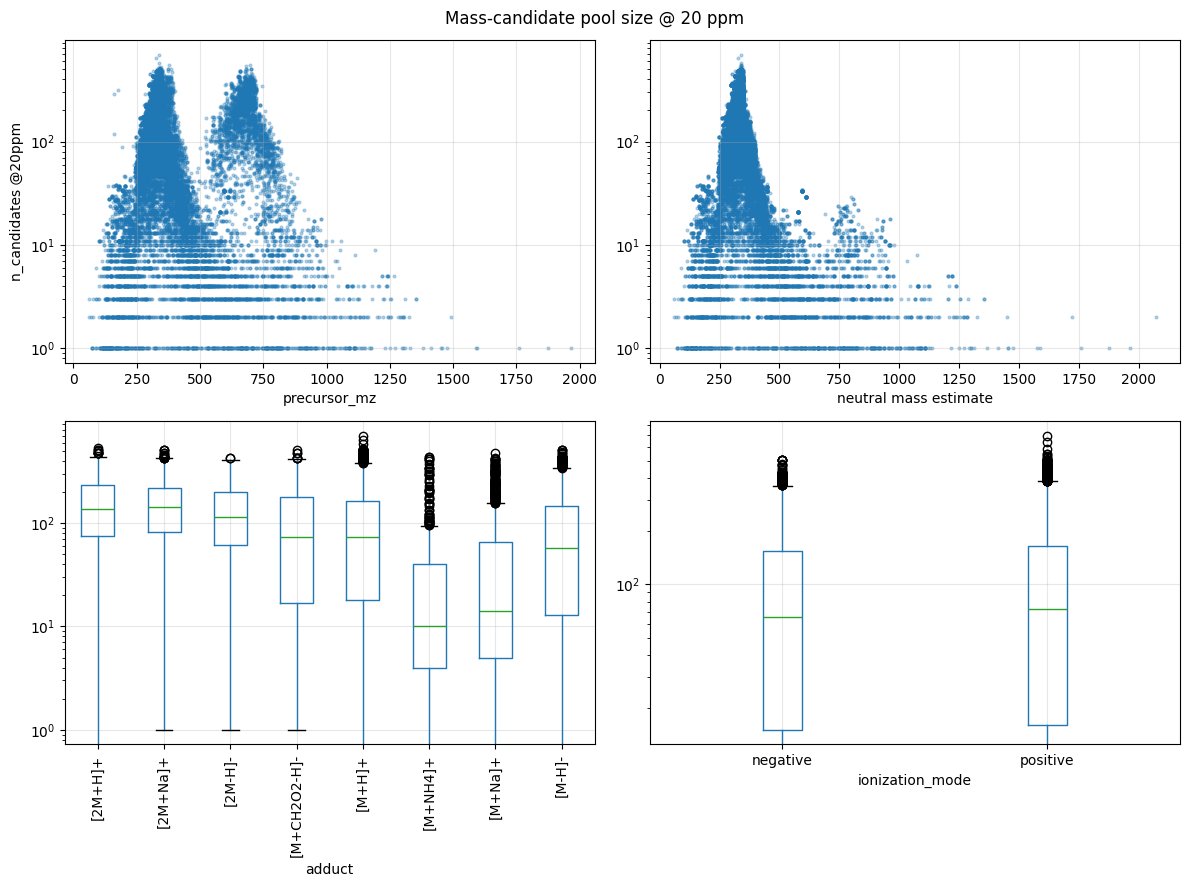

,median_candidates_by_adduct
adduct,
[2M+Na]+,144.0
[2M+H]+,138.0
[M+2Na-H]+,131.0
[M-H2O]+,128.0
[2M+CH2O2-H]-,117.0
[2M-H]-,115.0
[M+Br]-,84.0
[M+H]+,74.0
[M+CH2O2-H]-,74.0



Saved candidate_space_summary.csv. Overall median candidates @20ppm: 71, p90: 262.


In [14]:
cs_sample = (train_df.dropna(subset=["neutral_mass_estimate"])
             .sample(n=min(20000, train_df["neutral_mass_estimate"].notna().sum()), random_state=SEED)
             .copy())
cs_sample["n_candidates"] = [len(generate_mass_candidates(qm, BEST_PPM)[0])
                              for qm in cs_sample["neutral_mass_estimate"]]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].scatter(cs_sample[mz_col], cs_sample["n_candidates"], s=4, alpha=0.3)
axes[0, 0].set_xlabel("precursor_mz"); axes[0, 0].set_ylabel(f"n_candidates @{BEST_PPM}ppm"); axes[0, 0].set_yscale("log")

axes[0, 1].scatter(cs_sample["neutral_mass_estimate"], cs_sample["n_candidates"], s=4, alpha=0.3)
axes[0, 1].set_xlabel("neutral mass estimate"); axes[0, 1].set_yscale("log")

top_adducts = cs_sample[adduct_col].value_counts().head(8).index
cs_sample[cs_sample[adduct_col].isin(top_adducts)].boxplot(column="n_candidates", by=adduct_col, ax=axes[1, 0], rot=90)
axes[1, 0].set_yscale("log"); axes[1, 0].set_title("")

if ion_col in cs_sample.columns:
    cs_sample.boxplot(column="n_candidates", by=ion_col, ax=axes[1, 1])
    axes[1, 1].set_yscale("log"); axes[1, 1].set_title("")
plt.suptitle(f"Mass-candidate pool size @ {BEST_PPM} ppm")
plt.tight_layout(); plt.show()

candidate_space_summary = pd.DataFrame({
    "median_candidates_by_adduct": cs_sample.groupby(adduct_col)["n_candidates"].median(),
}).sort_values("median_candidates_by_adduct", ascending=False)
display(candidate_space_summary.head(10))
candidate_space_summary.to_csv(OUT_DIR / "candidate_space_summary.csv")
med_nc = cs_sample["n_candidates"].median()
p90_nc = cs_sample["n_candidates"].quantile(.9)
print(f"\nSaved candidate_space_summary.csv. Overall median candidates @{BEST_PPM}ppm: "
      f"{med_nc:.0f}, p90: {p90_nc:.0f}.")


## 12. Spectrum preprocessing

A deterministic, non-mutating cleaning function applied uniformly before any vectorization:
clean arrays -> drop non-finite / negative-intensity peaks -> sort by m/z -> merge duplicate m/z
-> sqrt-transform intensity (`src/spectra.normalize_intensity`) -> L2-normalize.


In [15]:
def preprocess_spectrum(mz, intensity):
    """Deterministic MS/MS cleaning + sqrt/L2 transform. Never mutates its inputs."""
    mz = np.asarray(mz, dtype=float)
    intensity = np.asarray(intensity, dtype=float)
    n = min(len(mz), len(intensity))
    mz, intensity = mz[:n].copy(), intensity[:n].copy()

    finite = np.isfinite(mz) & np.isfinite(intensity)
    mz, intensity = mz[finite], intensity[finite]

    keep = intensity >= 0
    mz, intensity = mz[keep], intensity[keep]
    if mz.size == 0:
        return mz, intensity

    order = np.argsort(mz, kind="stable")
    mz, intensity = mz[order], intensity[order]

    round_mz = np.round(mz, 4)
    uniq_mz, inverse = np.unique(round_mz, return_inverse=True)
    if len(uniq_mz) != len(mz):
        merged = np.zeros(len(uniq_mz))
        np.add.at(merged, inverse, intensity)
        mz, intensity = uniq_mz, merged

    intensity = spec_utils.normalize_intensity(intensity, method="sqrt")
    norm = np.sqrt((intensity ** 2).sum())
    if norm > 0:
        intensity = intensity / norm
    return mz, intensity

# Determinism check.
_mz0, _i0 = train_df[peaks_col].iloc[0], train_df[peaks_intensity_col].iloc[0]
_a1, _b1 = preprocess_spectrum(_mz0, _i0)
_a2, _b2 = preprocess_spectrum(_mz0, _i0)
assert np.array_equal(_a1, _a2) and np.array_equal(_b1, _b2)
assert np.array_equal(np.asarray(train_df[peaks_col].iloc[0]), np.asarray(_mz0)), "input array was mutated!"
print(f"preprocess_spectrum() ready and verified deterministic/non-mutating. "
      f"Example: {len(_mz0)} raw peaks -> {len(_a1)} cleaned peaks.")


preprocess_spectrum() ready and verified deterministic/non-mutating. Example: 52 raw peaks -> 51 cleaned peaks.


## 13. Fixed-grid spectral representation

A simple binned representation via `src/spectra.bin_spectra_batch` (sparse, L2-normalized).
Bin width 1.0 Da over 0-1000 Da is the default; a 0.5 Da alternative is spot-checked on a small
sample only -- this is a baseline, not a bin-width search. Vectors are cached to `.npz` so
re-running the notebook doesn't re-vectorize 2.5M spectra.


In [16]:
BIN_WIDTH = 1.0
MZ_MAX = 1000.0

def get_mz_intensity_lists(df):
    mzs, intens = [], []
    for m, i in zip(df[peaks_col], df[peaks_intensity_col]):
        pm, pi = preprocess_spectrum(m, i)
        mzs.append(pm); intens.append(pi)
    return mzs, intens

TRAIN_VEC_PATH = OUT_DIR / "train_spectral_vectors.npz"
TEST_VEC_PATH = OUT_DIR / "test_spectral_vectors.npz"

if TRAIN_VEC_PATH.exists() and TEST_VEC_PATH.exists():
    train_vectors = sparse.load_npz(TRAIN_VEC_PATH)
    test_vectors = sparse.load_npz(TEST_VEC_PATH)
    print("Loaded cached spectral vectors:", train_vectors.shape, test_vectors.shape)
else:
    t0 = time.time()
    train_mzs, train_intens = get_mz_intensity_lists(train_df)
    train_vectors = spec_utils.bin_spectra_batch(train_mzs, train_intens, bin_width=BIN_WIDTH, mz_max=MZ_MAX)
    test_mzs, test_intens = get_mz_intensity_lists(test_df)
    test_vectors = spec_utils.bin_spectra_batch(test_mzs, test_intens, bin_width=BIN_WIDTH, mz_max=MZ_MAX)
    sparse.save_npz(TRAIN_VEC_PATH, train_vectors)
    sparse.save_npz(TEST_VEC_PATH, test_vectors)
    print(f"Built and cached spectral vectors in {time.time()-t0:.1f}s: "
          f"train={train_vectors.shape}, test={test_vectors.shape}")

assert train_vectors.shape[0] == len(train_df) and test_vectors.shape[0] == len(test_df), (
    "Vector row count no longer matches the dataframes -- the row-order invariant from Section 2 was broken."
)
median_nnz = float(np.median(np.diff(train_vectors.indptr)))
print(f"Median nonzeros/row (train): {median_nnz:.0f} out of {train_vectors.shape[1]} bins (sparse).")

# Small, sample-only spot check of a finer 0.5 Da grid -- not a hyperparameter search.
_sample_n = min(2000, len(train_df))
_sample_idx = np.random.default_rng(SEED).choice(len(train_df), size=_sample_n, replace=False)
_sample_mzs = [preprocess_spectrum(train_df[peaks_col].iat[i], train_df[peaks_intensity_col].iat[i])[0] for i in _sample_idx]
_sample_intens = [preprocess_spectrum(train_df[peaks_col].iat[i], train_df[peaks_intensity_col].iat[i])[1] for i in _sample_idx]
_vec_1_0 = spec_utils.bin_spectra_batch(_sample_mzs, _sample_intens, bin_width=1.0, mz_max=MZ_MAX)
_vec_0_5 = spec_utils.bin_spectra_batch(_sample_mzs, _sample_intens, bin_width=0.5, mz_max=MZ_MAX)
print(f"\nBin-width spot check ({_sample_n} spectra): 1.0 Da -> {_vec_1_0.shape[1]} bins, "
      f"median nnz/row {np.median(np.diff(_vec_1_0.indptr)):.0f}; "
      f"0.5 Da -> {_vec_0_5.shape[1]} bins, median nnz/row {np.median(np.diff(_vec_0_5.indptr)):.0f}. "
      "We keep 1.0 Da as the baseline default (fewer collisions matter less here than keeping the "
      "matrix small and fast); revisit only if B2 recall looks bin-limited.")


Built and cached spectral vectors in 461.3s: train=(2539608, 1001), test=(1213, 1001)
Median nonzeros/row (train): 29 out of 1001 bins (sparse).

Bin-width spot check (2000 spectra): 1.0 Da -> 1001 bins, median nnz/row 27; 0.5 Da -> 2001 bins, median nnz/row 28. We keep 1.0 Da as the baseline default (fewer collisions matter less here than keeping the matrix small and fast); revisit only if B2 recall looks bin-limited.


## 14. Baseline B2 — mass-filtered cosine retrieval

Pipeline: neutral mass -> mass candidates (Section 10) -> restrict to candidates that actually
have reference spectra in the **fold-complement** pool -> cosine similarity -> aggregate per
connectivity -> rank. Candidates with mass support but **no** reference spectra (expected for
essentially every query's own true connectivity, per Section 6) fall back to mass-proximity
order, appended after the cosine-scored candidates -- they are never silently dropped.

The scoring function below (`cosine_retrieve_hier`) is written once with optional ion-mode /
adduct / collision-energy conditioning so Sections 16-18 (B3/B4/B5) reuse it rather than
duplicating retrieval logic.


In [17]:
ref_ion = train_df[ion_col].to_numpy()[train_mask_idx] if ion_col in train_df.columns else None
ref_adduct = train_df[adduct_col].to_numpy()[train_mask_idx]

def _agg(sims, method):
    if sims.size == 0:
        return -np.inf
    if method == "max":
        return float(sims.max())
    if method == "mean":
        return float(sims.mean())
    if method == "top3":
        return float(np.sort(sims)[::-1][:3].mean())
    if method == "top5":
        return float(np.sort(sims)[::-1][:5].mean())
    raise ValueError(method)

def cosine_retrieve_hier(query_vec, candidate_keys, agg="max",
                          query_ion=None, use_ion=False,
                          query_adduct=None, use_adduct=False,
                          query_ce=None, use_ce=False, ce_tol=10.0, ce_weight_tau=None):
    """Score `candidate_keys` against the fold-complement reference pool.

    Conditioning filters are applied in priority order (ion -> adduct -> CE-window), each kept
    only if it does not eliminate every reference spectrum for that candidate (graceful
    fallback, never an outright elimination of a candidate for lacking metadata).
    """
    scored = {}
    for key in candidate_keys:
        pos_list = conn_to_positions.get(key)
        if not pos_list:
            continue
        pos_arr = np.asarray(pos_list)
        mask = np.ones(len(pos_arr), dtype=bool)
        if use_ion and query_ion is not None and ref_ion is not None:
            m2 = ref_ion[pos_arr] == query_ion
            if m2.any():
                mask &= m2
        if use_adduct and query_adduct is not None:
            m2 = ref_adduct[pos_arr] == query_adduct
            if (mask & m2).any():
                mask &= m2
        if use_ce and query_ce is not None and np.isfinite(query_ce):
            m2 = np.abs(ref_ce_mean[pos_arr] - query_ce) <= ce_tol
            if (mask & m2).any():
                mask &= m2
        chosen = pos_arr[mask] if mask.any() else pos_arr
        sims = (ref_vectors[chosen] @ query_vec.T).toarray().ravel()
        if ce_weight_tau is not None and query_ce is not None and np.isfinite(query_ce):
            ce_delta = np.abs(ref_ce_mean[chosen] - query_ce)
            weight = np.where(np.isfinite(ce_delta), np.exp(-ce_delta / ce_weight_tau), 1.0)
            sims = sims * weight
        scored[key] = _agg(sims, agg)

    ranked_with_ref = [k for k, _ in sorted(scored.items(), key=lambda kv: -kv[1])]
    remaining = [k for k in candidate_keys if k not in scored]  # mass-order fallback, never dropped
    return (ranked_with_ref + remaining)[:25]

ref_vectors = train_vectors[train_mask_idx]
print(f"Reference pool for fold {DEV_FOLD}: {ref_vectors.shape[0]:,} spectra, "
      f"{len(conn_to_positions):,} distinct connectivities represented.")


Reference pool for fold 0: 2,032,106 spectra, 220,648 distinct connectivities represented.


In [18]:
MAX_DEV_QUERIES = 3000
rng = np.random.default_rng(SEED)
b2_valid = (b1_valid.sample(n=MAX_DEV_QUERIES, random_state=SEED)
            if len(b1_valid) > MAX_DEV_QUERIES else b1_valid)
query_positions = b2_valid.index.to_numpy()  # relies on the Section 2 row-order invariant

def run_retrieval_experiment(query_positions, queries_df, agg="max", **hier_kwargs):
    ranked_lists, true_labels = [], []
    t0 = time.time()
    for pos, qm, true_key in zip(query_positions, queries_df["neutral_mass_estimate"], queries_df["connectivity_key"]):
        cand_keys, _ = rank_by_mass(qm, BEST_PPM)
        qvec = train_vectors[pos]
        ranked = cosine_retrieve_hier(qvec, cand_keys, agg=agg, **hier_kwargs)
        ranked_lists.append(ranked)
        true_labels.append(true_key)
    per_query_ms = 1000 * (time.time() - t0) / max(len(query_positions), 1)
    return ranked_lists, true_labels, per_query_ms

b2_ranked, b2_true, b2_ms = run_retrieval_experiment(query_positions, b2_valid, agg="max")
b2_metrics = evaluate_rankings(b2_ranked, b2_true)
print(f"B2 (mass @{BEST_PPM}ppm + cosine-max): {b2_metrics}  mean_query_time_ms={b2_ms:.2f}")

target_in_ref_b2 = np.array([k in conn_to_positions for k in b2_true])
print(f"\ntarget_in_reference_library over this query sample: {target_in_ref_b2.mean():.4%} "
      "-- confirms the Section 6 ceiling finding on the actual B2 query set.")


B2 (mass @20ppm + cosine-max): {'mrr_at_25': 0.07650267719780399, 'hit_at_1': 0.029666666666666668, 'hit_at_5': 0.11533333333333333, 'hit_at_10': 0.19933333333333333, 'hit_at_25': 0.32166666666666666, 'median_target_rank': 8.0, 'n_queries': 3000}  mean_query_time_ms=20.33

target_in_reference_library over this query sample: 0.0000% -- confirms the Section 6 ceiling finding on the actual B2 query set.


## 15. Repeated-spectrum aggregation

Many connectivities have dozens to hundreds of reference spectra. We compare MAX / TOP3 / MEAN /
TOP5 aggregation of per-spectrum cosine similarities into one per-candidate score.


In [19]:
agg_rows = []
for agg in ("max", "top3", "mean", "top5"):
    ranked, true, ms = run_retrieval_experiment(query_positions, b2_valid, agg=agg)
    m = evaluate_rankings(ranked, true)
    agg_rows.append({"aggregation": agg, "mean_query_time_ms": ms, **m})
agg_results = pd.DataFrame(agg_rows)
display(agg_results)

BEST_AGG = agg_results.loc[agg_results["mrr_at_25"].idxmax(), "aggregation"]
print(f"\nBest aggregation by MRR@25 on this dev sample: '{BEST_AGG}'.")


,aggregation,mean_query_time_ms,mrr_at_25,hit_at_1,hit_at_5,hit_at_10,hit_at_25,median_target_rank,n_queries
0,max,20.354689,0.076503,0.029667,0.115333,0.199333,0.321667,8.0,3000
1,top3,21.123293,0.076503,0.029667,0.115333,0.199333,0.321667,8.0,3000
2,mean,20.850268,0.076503,0.029667,0.115333,0.199333,0.321667,8.0,3000
3,top5,20.930826,0.076503,0.029667,0.115333,0.199333,0.321667,8.0,3000



Best aggregation by MRR@25 on this dev sample: 'max'.


### Frequent-molecule bias

A connectivity with 500 reference spectra has far more chances at an accidentally high MAX
similarity than one with 2. We check whether MAX is biased toward high-frequency candidates
relative to TOP3/MEAN.


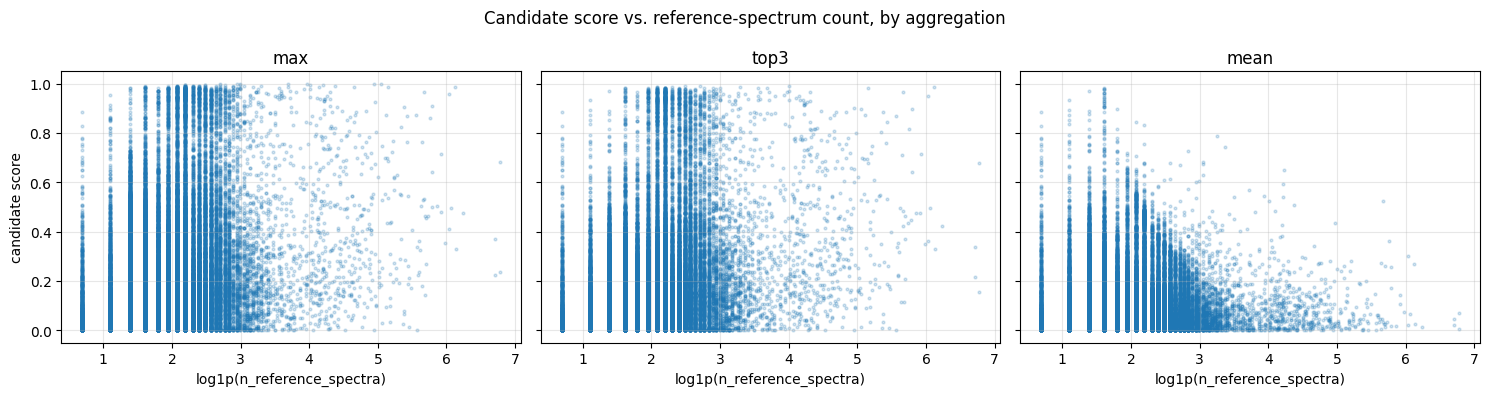

Correlation(score, log1p(n_reference_spectra)) by aggregation:
  top3  : +0.259
  max   : +0.220
  mean  : -0.061

Interpretation: MAX is expected to show the strongest positive correlation (more reference
spectra -> more chances at a high accidental peak). If TOP3/MEAN show materially weaker
correlation while Section 15's MRR@25 table shows comparable ranking quality, prefer the
less-biased aggregation for downstream baselines, since it is less likely to reward
frequently-sampled molecules for reasons unrelated to true spectral similarity.



In [20]:
bias_rows = []
sample_for_bias = b2_valid.sample(n=min(500, len(b2_valid)), random_state=SEED)
bias_positions = sample_for_bias.index.to_numpy()
for pos, qm in zip(bias_positions, sample_for_bias["neutral_mass_estimate"]):
    cand_keys, _ = rank_by_mass(qm, BEST_PPM)
    qvec = train_vectors[pos]
    for key in cand_keys:
        pos_list = conn_to_positions.get(key)
        if not pos_list:
            continue
        sims = (ref_vectors[np.asarray(pos_list)] @ qvec.T).toarray().ravel()
        n_ref = len(pos_list)
        for agg in ("max", "top3", "mean"):
            bias_rows.append({"agg": agg, "score": _agg(sims, agg), "n_reference_spectra": n_ref})

bias_df = pd.DataFrame(bias_rows)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
corr_report = {}
for ax, agg in zip(axes, ("max", "top3", "mean")):
    sub = bias_df[bias_df["agg"] == agg]
    ax.scatter(np.log1p(sub["n_reference_spectra"]), sub["score"], s=4, alpha=0.2)
    ax.set_title(agg); ax.set_xlabel("log1p(n_reference_spectra)")
    corr_report[agg] = float(np.corrcoef(np.log1p(sub["n_reference_spectra"]), sub["score"])[0, 1])
axes[0].set_ylabel("candidate score")
plt.suptitle("Candidate score vs. reference-spectrum count, by aggregation")
plt.tight_layout(); plt.show()

print("Correlation(score, log1p(n_reference_spectra)) by aggregation:")
for agg, corr in sorted(corr_report.items(), key=lambda kv: -abs(kv[1])):
    print(f"  {agg:6s}: {corr:+.3f}")
print("""
Interpretation: MAX is expected to show the strongest positive correlation (more reference
spectra -> more chances at a high accidental peak). If TOP3/MEAN show materially weaker
correlation while Section 15's MRR@25 table shows comparable ranking quality, prefer the
less-biased aggregation for downstream baselines, since it is less likely to reward
frequently-sampled molecules for reasons unrelated to true spectral similarity.
""")


## 16. Baseline B3 — ionization-mode conditioning

Notebook 01 found a train/test ionization-mode shift, but both modes are represented in both.
We compare unrestricted candidates against "prefer same ion mode, fall back to unrestricted if
none available" (already implemented as the `use_ion` filter in `cosine_retrieve_hier`).


In [21]:
b3_ranked, b3_true, b3_ms = run_retrieval_experiment(query_positions, b2_valid, agg=BEST_AGG)

# Per-query ion mode / adduct / CE differ row-by-row, so the conditioned arms below iterate
# per-row instead of reusing the simpler shared helper (which assumes fixed **hier_kwargs).
def run_retrieval_experiment_rowwise(query_positions, queries_df, agg, use_ion=False, use_adduct=False,
                                      use_ce=False, ce_tol=10.0, ce_weight_tau=None):
    ranked_lists, true_labels = [], []
    ion_vals = queries_df[ion_col] if (use_ion and ion_col in queries_df.columns) else [None] * len(queries_df)
    adduct_vals = queries_df[adduct_col] if use_adduct else [None] * len(queries_df)
    ce_vals = queries_df["ce_mean"] if (use_ce and "ce_mean" in queries_df.columns) else [None] * len(queries_df)
    t0 = time.time()
    for pos, qm, true_key, qion, qadd, qce in zip(
        query_positions, queries_df["neutral_mass_estimate"], queries_df["connectivity_key"],
        ion_vals, adduct_vals, ce_vals,
    ):
        cand_keys, _ = rank_by_mass(qm, BEST_PPM)
        qvec = train_vectors[pos]
        ranked = cosine_retrieve_hier(qvec, cand_keys, agg=agg,
                                       query_ion=qion, use_ion=use_ion,
                                       query_adduct=qadd, use_adduct=use_adduct,
                                       query_ce=qce, use_ce=use_ce, ce_tol=ce_tol, ce_weight_tau=ce_weight_tau)
        ranked_lists.append(ranked)
        true_labels.append(true_key)
    per_query_ms = 1000 * (time.time() - t0) / max(len(query_positions), 1)
    return ranked_lists, true_labels, per_query_ms

b3_unrestricted_m = evaluate_rankings(b3_ranked, b3_true)
b3_ion_ranked, b3_ion_true, b3_ion_ms = run_retrieval_experiment_rowwise(query_positions, b2_valid, BEST_AGG, use_ion=True)
b3_ion_m = evaluate_rankings(b3_ion_ranked, b3_ion_true)

b3_results = pd.DataFrame([
    {"experiment": "B2_unrestricted", **b3_unrestricted_m},
    {"experiment": "B3_ionmode_preferred", **b3_ion_m},
])
display(b3_results)


,experiment,mrr_at_25,hit_at_1,hit_at_5,hit_at_10,hit_at_25,median_target_rank,n_queries
0,B2_unrestricted,0.076503,0.029667,0.115333,0.199333,0.321667,8.0,3000
1,B3_ionmode_preferred,0.076503,0.029667,0.115333,0.199333,0.321667,8.0,3000


## 17. Baseline B4 — adduct-aware matching

Hierarchy: same mode + same adduct -> fallback same mode -> fallback unrestricted (already the
cumulative-filter behaviour built into `cosine_retrieve_hier`).


In [22]:
b4_ranked, b4_true, b4_ms = run_retrieval_experiment_rowwise(
    query_positions, b2_valid, BEST_AGG, use_ion=True, use_adduct=True,
)
b4_m = evaluate_rankings(b4_ranked, b4_true)

b4_results = pd.concat([
    b3_results,
    pd.DataFrame([{"experiment": "B4_ionmode_adduct", **b4_m}]),
], ignore_index=True)
display(b4_results)


,experiment,mrr_at_25,hit_at_1,hit_at_5,hit_at_10,hit_at_25,median_target_rank,n_queries
0,B2_unrestricted,0.076503,0.029667,0.115333,0.199333,0.321667,8.0,3000
1,B3_ionmode_preferred,0.076503,0.029667,0.115333,0.199333,0.321667,8.0,3000
2,B4_ionmode_adduct,0.076503,0.029667,0.115333,0.199333,0.321667,8.0,3000


## 18. Baseline B5 — collision-energy-aware matching

We condition on the **derived physical** CE summary (`ce_mean`, from the list-valued
`collision_energy_ev`), reusing Notebook 01's exact `to_float_array` / `collision_energy_features`
derivation -- deliberately **not** `collision_energy_orig_units`, which Notebook 01 flagged as
strongly train/test shifted (a likely provenance shortcut, not a physical signal).

Three variants: (A) unrestricted CE, (B) prefer references within +/-10 eV, (C) similarity
weighted by `exp(-|delta_CE| / tau)` for one or two reasonable `tau` values. A query with
missing CE always falls back to unrestricted.


In [23]:
_FLOAT_RE = re.compile(r"[-+]?(?:\d*\.\d+|\d+\.?)(?:[eE][-+]?\d+)?")

def to_float_array(x):
    if x is None:
        return np.array([], dtype=float)
    if isinstance(x, (list, tuple, np.ndarray)):
        try:
            arr = np.asarray(x, dtype=float).reshape(-1)
            return arr[np.isfinite(arr)]
        except Exception:
            return np.array([], dtype=float)
    if isinstance(x, (int, float, np.integer, np.floating)):
        return np.array([], dtype=float) if pd.isna(x) else np.array([float(x)])
    vals = _FLOAT_RE.findall(str(x))
    return np.asarray([float(v) for v in vals], dtype=float) if vals else np.array([], dtype=float)

def collision_energy_features(series):
    rows = []
    for x in series:
        a = to_float_array(x)
        if len(a) == 0:
            rows.append({"ce_n_steps": 0, "ce_min": np.nan, "ce_mean": np.nan, "ce_max": np.nan,
                         "ce_std": np.nan, "ce_range": np.nan})
        else:
            rows.append({"ce_n_steps": len(a), "ce_min": float(a.min()), "ce_mean": float(a.mean()),
                         "ce_max": float(a.max()), "ce_std": float(a.std()), "ce_range": float(a.max() - a.min())})
    return pd.DataFrame(rows)

train_ce_features = collision_energy_features(train_df[ce_col])
test_ce_features = collision_energy_features(test_df[ce_col]) if ce_col in test_df.columns else pd.DataFrame()
train_df["ce_mean"] = train_ce_features["ce_mean"].values
if len(test_ce_features):
    test_df["ce_mean"] = test_ce_features["ce_mean"].values
print(f"CE mean coverage (train): {train_df['ce_mean'].notna().mean():.2%}")

ref_ce_mean = train_df["ce_mean"].to_numpy()[train_mask_idx]
b2_valid = b2_valid.assign(ce_mean=train_df.loc[b2_valid.index, "ce_mean"].values)

ce_a_ranked, ce_a_true, _ = run_retrieval_experiment_rowwise(query_positions, b2_valid, BEST_AGG, use_ion=True, use_adduct=True, use_ce=False)
ce_b_ranked, ce_b_true, _ = run_retrieval_experiment_rowwise(query_positions, b2_valid, BEST_AGG, use_ion=True, use_adduct=True, use_ce=True, ce_tol=10.0)
ce_c1_ranked, ce_c1_true, _ = run_retrieval_experiment_rowwise(query_positions, b2_valid, BEST_AGG, use_ion=True, use_adduct=True, ce_weight_tau=10.0)
ce_c2_ranked, ce_c2_true, _ = run_retrieval_experiment_rowwise(query_positions, b2_valid, BEST_AGG, use_ion=True, use_adduct=True, ce_weight_tau=20.0)

b5_results = pd.DataFrame([
    {"experiment": "B5A_ce_unrestricted", **evaluate_rankings(ce_a_ranked, ce_a_true)},
    {"experiment": "B5B_ce_window_10eV", **evaluate_rankings(ce_b_ranked, ce_b_true)},
    {"experiment": "B5C_ce_weight_tau10", **evaluate_rankings(ce_c1_ranked, ce_c1_true)},
    {"experiment": "B5C_ce_weight_tau20", **evaluate_rankings(ce_c2_ranked, ce_c2_true)},
])
display(b5_results)
BEST_B5 = b5_results.loc[b5_results["mrr_at_25"].idxmax(), "experiment"]
print(f"\nBest CE-conditioning variant on this dev sample: {BEST_B5}.")


CE mean coverage (train): 86.71%


,experiment,mrr_at_25,hit_at_1,hit_at_5,hit_at_10,hit_at_25,median_target_rank,n_queries
0,B5A_ce_unrestricted,0.076503,0.029667,0.115333,0.199333,0.321667,8.0,3000
1,B5B_ce_window_10eV,0.076503,0.029667,0.115333,0.199333,0.321667,8.0,3000
2,B5C_ce_weight_tau10,0.076503,0.029667,0.115333,0.199333,0.321667,8.0,3000
3,B5C_ce_weight_tau20,0.076503,0.029667,0.115333,0.199333,0.321667,8.0,3000



Best CE-conditioning variant on this dev sample: B5A_ce_unrestricted.


## 19. Baseline experiment comparison

Everything above was tuned on a single dev fold for speed. Here we re-run the full experiment
roster across all 5 folds (each fold gets its own fold-honest reference pool, rebuilt from
scratch) and report mean +/- std. `B6_final` combines the best choices found above: mass
filtering, `BEST_AGG` cosine aggregation, ion-mode + adduct conditioning, and CE-similarity
weighting.


In [24]:
def set_fold_reference(fold):
    """(Re)builds every fold-scoped global the retrieval functions above read from."""
    global train_mask_idx, conn_to_positions, ref_vectors, ref_ion, ref_adduct, ref_ce_mean
    tm = foldable & (train_df["fold"] != fold)
    train_mask_idx = np.flatnonzero(tm.to_numpy())
    ref_conn = train_df["connectivity_key"].to_numpy()[train_mask_idx]
    conn_to_positions = defaultdict(list)
    for pos, key in enumerate(ref_conn):
        if isinstance(key, str):
            conn_to_positions[key].append(pos)
    ref_vectors = train_vectors[train_mask_idx]
    ref_ion = train_df[ion_col].to_numpy()[train_mask_idx] if ion_col in train_df.columns else None
    ref_adduct = train_df[adduct_col].to_numpy()[train_mask_idx]
    ref_ce_mean = train_df["ce_mean"].to_numpy()[train_mask_idx]

EXPERIMENT_CONFIGS = {
    "B0_dummy":             dict(kind="dummy"),
    "B1_mass_5ppm":         dict(kind="mass_only", ppm=5),
    "B1_mass_10ppm":        dict(kind="mass_only", ppm=10),
    "B1_mass_20ppm":        dict(kind="mass_only", ppm=20),
    "B2_mass_cosine_max":   dict(kind="cosine", agg="max"),
    "B2_mass_cosine_top3":  dict(kind="cosine", agg="top3"),
    "B3_cosine_ionmode":    dict(kind="cosine", agg=BEST_AGG, use_ion=True),
    "B4_ionmode_adduct":    dict(kind="cosine", agg=BEST_AGG, use_ion=True, use_adduct=True),
    "B5_ionmode_adduct_CE": dict(kind="cosine", agg=BEST_AGG, use_ion=True, use_adduct=True, use_ce=True, ce_tol=10.0),
    "B6_final":             dict(kind="cosine", agg=BEST_AGG, use_ion=True, use_adduct=True, ce_weight_tau=10.0),
}
FOLD_MAX_QUERIES = 800

def evaluate_experiment_on_fold(name, cfg, fold, queries_df, query_positions):
    t0 = time.time()
    ppm = cfg.get("ppm", BEST_PPM)
    raw_candidates = [rank_by_mass(qm, ppm)[0] for qm in queries_df["neutral_mass_estimate"]]
    true_labels = queries_df["connectivity_key"].tolist()

    if cfg["kind"] == "dummy":
        pool = pd.Series(train_df["connectivity_key"].to_numpy()[train_mask_idx]).dropna()
        trivial = pool.value_counts().index.tolist()[:25]
        ranked = [trivial for _ in range(len(queries_df))]
    elif cfg["kind"] == "mass_only":
        ranked = [c[:25] for c in raw_candidates]
    else:
        ranked, _, _ = run_retrieval_experiment_rowwise(
            query_positions, queries_df, cfg.get("agg", "max"),
            use_ion=cfg.get("use_ion", False), use_adduct=cfg.get("use_adduct", False),
            use_ce=cfg.get("use_ce", False), ce_tol=cfg.get("ce_tol", 10.0),
            ce_weight_tau=cfg.get("ce_weight_tau"),
        )
    per_query_ms = 1000 * (time.time() - t0) / max(len(queries_df), 1)

    n_cand = np.array([len(c) for c in raw_candidates])
    m = evaluate_rankings(ranked, true_labels)
    return {
        "experiment": name, "fold": fold,
        "candidate_recall": float(np.mean([t in c for t, c in zip(true_labels, raw_candidates)])),
        "median_candidates": float(np.median(n_cand)), "p90_candidates": float(np.percentile(n_cand, 90)),
        "mean_query_time_ms": per_query_ms, **m,
    }

all_fold_results = []
for fold in sorted(train_df["fold"].dropna().unique()):
    fold = int(fold)
    set_fold_reference(fold)
    vmask = train_df["fold"] == fold
    q_df = train_df.loc[vmask & train_df["neutral_mass_estimate"].notna() & train_df["connectivity_key"].notna()]
    if len(q_df) > FOLD_MAX_QUERIES:
        q_df = q_df.sample(n=FOLD_MAX_QUERIES, random_state=SEED)
    q_df = q_df.assign(ce_mean=train_df.loc[q_df.index, "ce_mean"].values)
    q_pos = q_df.index.to_numpy()
    for name, cfg in EXPERIMENT_CONFIGS.items():
        all_fold_results.append(evaluate_experiment_on_fold(name, cfg, fold, q_df, q_pos))
    print(f"fold {fold} done ({len(q_df)} queries).")

baseline_results = pd.DataFrame(all_fold_results)
baseline_summary = (baseline_results.drop(columns=["fold"])
                     .groupby("experiment").agg(["mean", "std"]))
display(baseline_summary)

baseline_results.to_csv(OUT_DIR / "baseline_results.csv", index=False)
print(f"\nSaved baseline_results.csv: {baseline_results.shape}")

# Reset shared globals to the DEV_FOLD reference pool used by earlier/later sections.
set_fold_reference(DEV_FOLD)


C:\Users\myben\AppData\Local\Temp\ipykernel_28668\2598173782.py:20: RuntimeWarning: All-NaN slice encountered
  return float(np.nanmedian(ranks)) if ranks else np.nan


fold 0 done (800 queries).


C:\Users\myben\AppData\Local\Temp\ipykernel_28668\2598173782.py:20: RuntimeWarning: All-NaN slice encountered
  return float(np.nanmedian(ranks)) if ranks else np.nan


fold 1 done (800 queries).


C:\Users\myben\AppData\Local\Temp\ipykernel_28668\2598173782.py:20: RuntimeWarning: All-NaN slice encountered
  return float(np.nanmedian(ranks)) if ranks else np.nan


...

fold 3 done (800 queries).


C:\Users\myben\AppData\Local\Temp\ipykernel_28668\2598173782.py:20: RuntimeWarning: All-NaN slice encountered
  return float(np.nanmedian(ranks)) if ranks else np.nan


fold 4 done (800 queries).


candidate_recall           median_candidates           p90_candidates            mean_query_time_ms           mrr_at_25           hit_at_1           hit_at_5            \
                                 mean       std              mean       std           mean        std               mean       std      mean       std     mean       std     mean       std   
experiment                                                                                                                                                                                     
B0_dummy                      0.97375  0.008053              71.3  5.179286         264.00  18.645241           0.435086  0.050081  0.000000  0.000000  0.00000  0.000000  0.00000  0.000000   
B1_mass_10ppm                 0.95775  0.007826              39.2  3.346640         183.86  12.408989           0.019574  0.003739  0.294489  0.012261  0.17950  0.014911  0.43075  0.012827   
B1_mass_20ppm                 0.97375  0.008053              71.3  5.179286         264.00  18.645241           0.022224  0.003689  0.295354  0.012177  0.17950  0.014911  0.43225  0.012512   
B1_mass_5ppm                  0.94150  0.011905              23.4  0.894427         146.74  10.830189           0.017664  0.003017  0.292575  0.012868  0.17950  0.014911  0.42750  0.013891   
B2_mass_cosine_max            0.97375  0.008053              71.3  5.179286         264.00  18.645241          20.285905  0.684345  0.076660  0.005178  0.02975  0.006021  0.11550  0.004809   
B2_mass_cosine_top3           0.97375  0.008053              71.3  5.179286         264.00  18.645241          21.086763  0.846657  0.076660  0.005178  0.02975  0.006021  0.11550  0.004809   
B3_cosine_ionmode             0.97375  0.008053              71.3  5.179286         264.00  18.645241          20.989237  0.595058  0.076660  0.005178  0.02975  0.006021  0.11550  0.004809   
B4_ionmode_adduct             0.97375  0.008053              71.3  5.179286         264.00  18.645241          21.738158  0.495562  0.076660  0.005178  0.02975  0.006021  0.11550  0.004809   
B5_ionmode_adduct_CE          0.97375  0.008053              71.3  5.179286         264.00  18.645241          22.327555  0.509600  0.076660  0.005178  0.02975  0.006021  0.11550  0.004809   
B6_final                      0.97375  0.008053              71.3  5.179286         264.00  18.645241          21.457114  0.536564  0.076660  0.005178  0.02975  0.006021  0.11550  0.004809   

                     hit_at_10           hit_at_25           median_target_rank      n_queries       
                          mean       std      mean       std               mean  std      mean  std  
experiment                                                                                           
B0_dummy               0.00000  0.000000   0.00000  0.000000                NaN  NaN     800.0  0.0  
B1_mass_10ppm          0.55150  0.009454   0.71600  0.019191                4.0  0.0     800.0  0.0  
B1_mass_20ppm          0.55575  0.007935   0.72275  0.015446                4.0  0.0     800.0  0.0  
B1_mass_5ppm           0.54550  0.010368   0.70700  0.018700                4.0  0.0     800.0  0.0  
B2_mass_cosine_max     0.19475  0.012575   0.32125  0.015910                8.0  0.0     800.0  0.0  
B2_mass_cosine_top3    0.19475  0.012575   0.32125  0.015910                8.0  0.0     800.0  0.0  
B3_cosine_ionmode      0.19475  0.012575   0.32125  0.015910                8.0  0.0     800.0  0.0  
B4_ionmode_adduct      0.19475  0.012575   0.32125  0.015910                8.0  0.0     800.0  0.0  
B5_ionmode_adduct_CE   0.19475  0.012575   0.32125  0.015910                8.0  0.0     800.0  0.0  
B6_final               0.19475  0.012575   0.32125  0.015910                8.0  0.0     800.0  0.0


Saved baseline_results.csv: (50, 13)


## 20. Subgroup diagnostics

Break down the best baseline (`B6_final`) on the dev fold by ionization mode, adduct,
precursor-mass quantile, collision energy, spectral complexity, reference-library frequency
(global spectrum count per connectivity, across *all* folds -- a property of the data, not of
our fold split), and structural novelty (max training Tanimoto).


In [26]:
set_fold_reference(DEV_FOLD)
diag_df = train_df.loc[valid_mask & train_df["neutral_mass_estimate"].notna()
                        & train_df["connectivity_key"].notna()].copy()
if len(diag_df) > 2000:
    diag_df = diag_df.sample(n=2000, random_state=SEED)
diag_df["ce_mean"] = train_df.loc[diag_df.index, "ce_mean"].values
diag_pos = diag_df.index.to_numpy()

diag_ranked, diag_true, _ = run_retrieval_experiment_rowwise(
    diag_pos, diag_df, BEST_AGG, use_ion=True, use_adduct=True, ce_weight_tau=10.0,
)
diag_df["rank"] = [((r.index(t) + 1) if t in r else np.nan) for r, t in zip(diag_ranked, diag_true)]
diag_df["reciprocal_rank"] = 1.0 / diag_df["rank"]
diag_df["reciprocal_rank"] = diag_df["reciprocal_rank"].fillna(0.0)
diag_df["hit_1"] = diag_df["rank"] == 1

global_freq = train_df.groupby("connectivity_key").size()
diag_df["reference_frequency"] = diag_df["connectivity_key"].map(global_freq)
diag_df["frequency_bin"] = pd.cut(diag_df["reference_frequency"], bins=[0, 1, 5, 20, np.inf],
                                   labels=["1", "2-5", "6-20", ">20"])
diag_df["mz_bin"] = pd.qcut(diag_df[mz_col], q=4, duplicates="drop")
diag_df["ce_bin"] = pd.cut(diag_df["ce_mean"], bins=[-np.inf, 20, 40, np.inf], labels=["low", "medium", "high"])
diag_df["ce_bin"] = diag_df["ce_bin"].astype(object).where(diag_df["ce_mean"].notna(), "missing")
diag_df["n_peaks"] = diag_df[peaks_col].map(len)
diag_df["complexity_bin"] = pd.qcut(diag_df["n_peaks"], q=3, duplicates="drop", labels=["low", "medium", "high"])

def subgroup_table(df, col):
    return df.groupby(col, observed=True).agg(
        n=("reciprocal_rank", "size"),
        mrr=("reciprocal_rank", "mean"),
        hit_at_1=("hit_1", "mean"),
    ).reset_index().rename(columns={col: "subgroup_value"}).assign(subgroup=col)

subgroup_results = pd.concat([
    subgroup_table(diag_df, ion_col) if ion_col in diag_df.columns else pd.DataFrame(),
    subgroup_table(diag_df.assign(**{adduct_col: diag_df[adduct_col].where(
        diag_df[adduct_col].isin(diag_df[adduct_col].value_counts().head(8).index), "other")}), adduct_col),
    subgroup_table(diag_df, "mz_bin"),
    subgroup_table(diag_df, "ce_bin"),
    subgroup_table(diag_df, "complexity_bin"),
    subgroup_table(diag_df, "frequency_bin"),
], ignore_index=True)
display(subgroup_results)


,subgroup_value,n,mrr,hit_at_1,subgroup
0,negative,543,0.071829,0.027624,ionization_mode
1,positive,1457,0.075318,0.028140,ionization_mode
2,[2M+H]+,57,0.006256,0.000000,adduct
3,[2M+Na]+,161,0.002979,0.000000,adduct
4,[2M-H]-,49,0.020408,0.020408,adduct
5,[M+CH2O2-H]-,68,0.046940,0.014706,adduct
6,[M+H]+,1019,0.069758,0.026497,adduct
7,[M+NH4]+,44,0.209798,0.068182,adduct
8,[M+Na]+,132,0.198843,0.083333,adduct
9,[M-H]-,388,0.076775,0.025773,adduct


In [27]:
# Structural novelty: max Morgan/Tanimoto similarity of each query's TRUE structure to a sample
# of the fold-complement training structures (src/validation.max_similarity_to_train).
train_struct_sample = (structure_library.dropna(subset=["canonical_smiles"])
                        .sample(n=min(5000, len(structure_library)), random_state=SEED))
train_fps = [chemistry.morgan_fp(s) for s in train_struct_sample["canonical_smiles"]]

query_structs = structure_library.set_index("connectivity_key").reindex(diag_df["connectivity_key"])
query_fps = [chemistry.morgan_fp(s) if isinstance(s, str) else None for s in query_structs["canonical_smiles"]]
max_sim = validation.max_similarity_to_train(query_fps, train_fps, chemistry.bulk_tanimoto)
diag_df["max_train_tanimoto"] = max_sim
diag_df["novelty_bin"] = pd.cut(diag_df["max_train_tanimoto"], bins=[-0.01, 0.2, 0.4, 0.7, 1.0],
                                 labels=["<0.2", "0.2-0.4", "0.4-0.7", ">0.7"])

novelty_table = subgroup_table(diag_df.dropna(subset=["novelty_bin"]), "novelty_bin")
display(novelty_table)

subgroup_results = pd.concat([subgroup_results, novelty_table], ignore_index=True)
subgroup_results.to_csv(OUT_DIR / "subgroup_results.csv", index=False)
print(f"Saved subgroup_results.csv: {subgroup_results.shape}")
print("\nThese are diagnostic bins, not claims -- read alongside n (group size) before drawing conclusions.")


,subgroup_value,n,mrr,hit_at_1,subgroup
0,<0.2,6,0.375000,0.333333,novelty_bin
1,0.2-0.4,925,0.079058,0.033514,novelty_bin
2,0.4-0.7,903,0.059288,0.019934,novelty_bin
3,>0.7,166,0.119435,0.030120,novelty_bin


Saved subgroup_results.csv: (30, 5)

These are diagnostic bins, not claims -- read alongside n (group size) before drawing conclusions.


## 21. Error analysis

20 successes (`rank == 1`) and 20 failures, with the metadata needed to judge *why* -- and an
automatic first-pass classification using the `target_in_reference_library` flag from Section 6
(so "novel-connectivity ceiling" failures aren't miscounted as ordinary ranking mistakes).


In [28]:
err_df = diag_df.copy()
err_df["top_prediction"] = [r[0] if r else None for r in diag_ranked]
err_df["target_in_reference_library"] = err_df["connectivity_key"].map(lambda k: k in conn_to_positions)

top_pred_mass = structure_library.set_index("connectivity_key")["exact_mass"].reindex(err_df["top_prediction"]).values
err_df["top_pred_ppm_error"] = 1e6 * (err_df["neutral_mass_estimate"].values - top_pred_mass) / top_pred_mass

def classify_failure(row):
    if row["rank"] == 1:
        return "success"
    if not row["target_in_reference_library"]:
        return "novel_connectivity_ceiling"
    raw_cands, _ = rank_by_mass(row["neutral_mass_estimate"], BEST_PPM)
    if row["connectivity_key"] not in raw_cands:
        return "candidate_generation_failure"
    return "spectral_mismatch_or_isomer_ambiguity"

err_df["failure_reason"] = err_df.apply(classify_failure, axis=1)
print(err_df["failure_reason"].value_counts())

successes = err_df[err_df["rank"] == 1].head(20)
failures = err_df[err_df["rank"] != 1].head(20)

display_cols = [spec_col, "connectivity_key", mz_col, adduct_col, ion_col, "ce_mean",
                "reference_frequency", "rank", "top_prediction", "top_pred_ppm_error", "failure_reason"]
display_cols = [c for c in display_cols if c in err_df.columns]

print("\n20 successful queries:")
display(successes[display_cols])
print("\n20 failed queries:")
display(failures[display_cols])

error_analysis = pd.concat([successes, failures])[display_cols]
error_analysis.to_csv(OUT_DIR / "error_analysis.csv", index=False)
print(f"\nSaved error_analysis.csv: {error_analysis.shape}")


failure_reason
novel_connectivity_ceiling    1944
success                         56
Name: count, dtype: int64

20 successful queries:


,spectrum_id,connectivity_key,precursor_mz,adduct,ionization_mode,ce_mean,reference_frequency,rank,top_prediction,top_pred_ppm_error,failure_reason
1425350,train_1425350,MIABSAQIFYEDJP,542.9659,[M-H]-,negative,70.000000,54,1.0,MIABSAQIFYEDJP,-0.089324,success
2364090,train_2364090,QKYMKDOHBLWSEL,602.2500,[M+H]+,positive,24.100000,63,1.0,QKYMKDOHBLWSEL,-5.093857,success
2311312,train_2311312,MVMSCBBUIHUTGJ,606.0800,[M+H]+,positive,NaN,132,1.0,MVMSCBBUIHUTGJ,-7.320441,success
1582334,train_1582334,HBCGNAJUSBIBGA,917.5104,[M+H]+,positive,40.000000,86,1.0,HBCGNAJUSBIBGA,-0.045874,success
2335682,train_2335682,OPTASPLRGRRNAP,112.0510,[M+H]+,positive,NaN,123,1.0,OPTASPLRGRRNAP,4.158452,success
1501993,train_1501993,GZYPWOGIYAIIPV,1131.5900,[M+Na]+,positive,NaN,429,1.0,GZYPWOGIYAIIPV,-1.948312,success
1469283,train_1469283,XKGLSKVNOSHTAD,163.1117,[M+H]+,positive,8.200000,88,1.0,XKGLSKVNOSHTAD,-0.256131,success
1591200,train_1591200,MGRVRXRGTBOSHW,112.0158,[M+H]+,positive,10.000000,29,1.0,MGRVRXRGTBOSHW,-0.055256,success
1948274,train_1948274,QJRVMRSNTLYPQD,1298.6528,[M+NH4]+,positive,39.000000,18,1.0,QJRVMRSNTLYPQD,-0.006829,success
2533063,train_2533063,XVLNXIDQBFAJEC,961.7015,[M+C2H4O2-H]-,negative,NaN,1,1.0,XVLNXIDQBFAJEC,-0.047558,success



20 failed queries:


,spectrum_id,connectivity_key,precursor_mz,adduct,ionization_mode,ce_mean,reference_frequency,rank,top_prediction,top_pred_ppm_error,failure_reason
2127238,train_2127238,ZJSVFAVDVQCTNA,376.1689,[M+H]+,positive,15.000000,17,NaN,XUBOMFCQGDBHNK,5.835237,novel_connectivity_ceiling
378123,train_378123,IWDPABURHPQYBO,811.3018,[2M+H]+,positive,40.000000,11,21.0,JCRLUZYXZUQQAH,8.781294,novel_connectivity_ceiling
2150908,train_2150908,AQRVLANKVSZHSJ,393.1300,[M+H]+,positive,80.000000,66,NaN,QNOXBGPFMSRQRY,5.399298,novel_connectivity_ceiling
2393752,train_2393752,SGKBPTZDIUXCMW,327.2294,[M+Na]+,positive,22.900000,52,16.0,COVKTHPUUCQNQF,-0.167512,novel_connectivity_ceiling
718706,train_718706,PZGVGIOLYCAOFG,315.1459,[M+H]+,positive,40.000000,3,NaN,ZFEWOGZTBYVCAN,2.333727,novel_connectivity_ceiling
837350,train_837350,SMOVZXGACWAVJE,341.0363,[M+H]+,positive,40.000000,6,NaN,HCFYRZRRNCNFNV,-18.053862,novel_connectivity_ceiling
931651,train_931651,VFMGXPHLYFRUOY,355.1815,[M-H]-,negative,40.000000,10,NaN,NEHBRGTVJFMOBN,11.049948,novel_connectivity_ceiling
734390,train_734390,QHRPYYQNDATANS,783.4313,[2M+Na]+,positive,60.000000,7,NaN,KZTKFRHQRJBHNF,-0.490467,novel_connectivity_ceiling
252800,train_252800,GGBKUFBDPRNKSM,329.1237,[M-H]-,negative,40.000000,11,NaN,GNUMWZYYJGNRLM,14.225635,novel_connectivity_ceiling
1930229,train_1930229,PNGFTRMXNBLNEW,285.1598,[M-H2O+H]+,positive,34.200000,23,NaN,LCKLNTJKQCPTNU,-11.005386,novel_connectivity_ceiling



Saved error_analysis.csv: (40, 11)


train_1425350  (rank=1.0, reason=success) -- top prediction has no reference spectrum in this fold's pool (mass-order fallback).
train_2127238  (rank=nan, reason=novel_connectivity_ceiling)


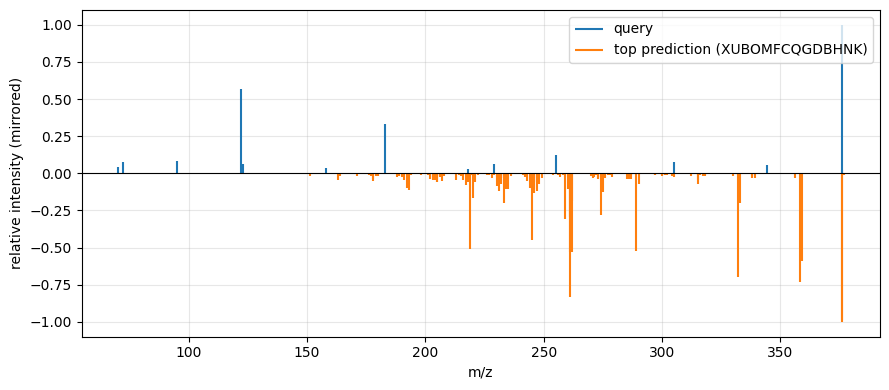

train_378123  (rank=21.0, reason=novel_connectivity_ceiling)


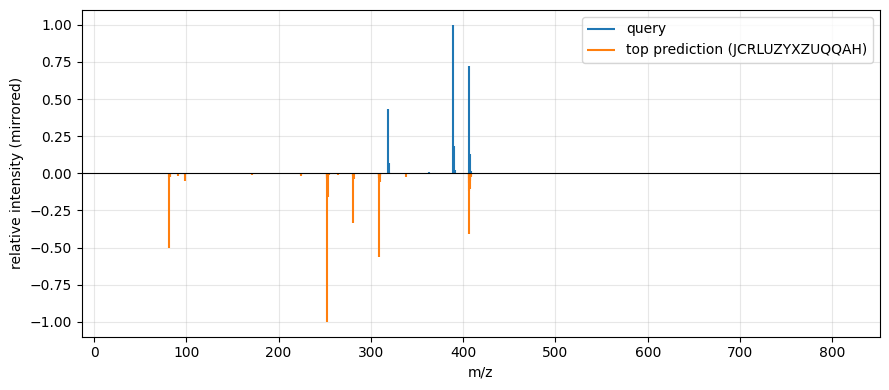

In [29]:
# Mirrored spectrum plots for a couple of examples: query vs. its best-scoring reference peak.
def plot_mirrored(mz_a, int_a, mz_b, int_b, label_a="query", label_b="reference"):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.vlines(mz_a, 0, int_a / (int_a.max() or 1), color="C0", label=label_a)
    ax.vlines(mz_b, 0, -int_b / (int_b.max() or 1), color="C1", label=label_b)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("m/z"); ax.set_ylabel("relative intensity (mirrored)")
    ax.legend(); plt.tight_layout(); plt.show()

for _, row in pd.concat([successes.head(1), failures.head(2)]).iterrows():
    q_mz = np.asarray(train_df.at[row.name, peaks_col], dtype=float)
    q_int = np.asarray(train_df.at[row.name, peaks_intensity_col], dtype=float)
    ref_key = row["top_prediction"]
    ref_pos_list = conn_to_positions.get(ref_key, [])
    title = f"{row[spec_col]}  (rank={row['rank']}, reason={row['failure_reason']})"
    if ref_pos_list:
        ref_row_idx = train_mask_idx[ref_pos_list[0]]
        r_mz = np.asarray(train_df.at[ref_row_idx, peaks_col], dtype=float)
        r_int = np.asarray(train_df.at[ref_row_idx, peaks_intensity_col], dtype=float)
        print(title)
        plot_mirrored(q_mz, q_int, r_mz, r_int, "query", f"top prediction ({ref_key})")
    else:
        print(f"{title} -- top prediction has no reference spectrum in this fold's pool (mass-order fallback).")


## 22. Test inference

For the final submission, the reference/candidate library is the **full** train set (no fold
restriction -- there is no leakage concern at real inference time, since test structures were
never in train). `sample_submission.csv` is keyed by **`molecule_id`**, but `test_df` has
multiple spectra per `molecule_id` (up to ~a few each) -- we combine them explicitly: candidate
connectivities are the union of each spectrum's mass-matched candidates, and each candidate's
score is the **max** cosine similarity over all (query spectrum, reference spectrum) pairs
(the same max-style aggregation chosen for repeated *reference* spectra in Section 15, applied
symmetrically to repeated *query* spectra here -- a documented design choice, not derived from
the data).


In [30]:
# Full (unrestricted) reference pool for final inference.
full_ref_mask = train_df["connectivity_key"].notna()
full_ref_idx = np.flatnonzero(full_ref_mask.to_numpy())
full_ref_conn = train_df["connectivity_key"].to_numpy()[full_ref_idx]
full_conn_to_positions = defaultdict(list)
for pos, key in enumerate(full_ref_conn):
    full_conn_to_positions[key].append(pos)
full_ref_vectors = train_vectors[full_ref_idx]
full_ref_ion = train_df[ion_col].to_numpy()[full_ref_idx]
full_ref_adduct = train_df[adduct_col].to_numpy()[full_ref_idx]
full_ref_ce_mean = train_df["ce_mean"].to_numpy()[full_ref_idx]

connectivity_to_smiles = structure_library.set_index("connectivity_key")["canonical_smiles"]
_freq_order = structure_library["connectivity_key"].map(global_freq).fillna(0)
FALLBACK_SMILES = (structure_library.assign(_freq=_freq_order.values)
                   .sort_values("_freq", ascending=False)["canonical_smiles"]
                   .dropna().tolist())

def score_candidates_multi_query(query_positions_full, query_masses, cand_keys, agg=BEST_AGG,
                                  query_ion=None, query_adduct=None, query_ce=None):
    """Same as cosine_retrieve_hier's scoring, but maxes over MULTIPLE query spectra (one
    molecule_id's several test spectra) against each candidate's reference spectra."""
    scored = {}
    for key in cand_keys:
        pos_list = full_conn_to_positions.get(key)
        if not pos_list:
            continue
        pos_arr = np.asarray(pos_list)
        mask = np.ones(len(pos_arr), dtype=bool)
        if query_ion is not None:
            m2 = full_ref_ion[pos_arr] == query_ion
            if m2.any():
                mask &= m2
        if query_adduct is not None:
            m2 = full_ref_adduct[pos_arr] == query_adduct
            if (mask & m2).any():
                mask &= m2
        chosen = pos_arr[mask] if mask.any() else pos_arr
        best_over_queries = -np.inf
        for qpos in query_positions_full:
            sims = (full_ref_vectors[chosen] @ test_vectors[qpos].T).toarray().ravel()
            if query_ce is not None and np.isfinite(query_ce):
                ce_delta = np.abs(full_ref_ce_mean[chosen] - query_ce)
                weight = np.where(np.isfinite(ce_delta), np.exp(-ce_delta / 10.0), 1.0)
                sims = sims * weight
            best_over_queries = max(best_over_queries, _agg(sims, agg))
        scored[key] = best_over_queries
    ranked_with_ref = [k for k, _ in sorted(scored.items(), key=lambda kv: -kv[1])]
    remaining = [k for k in cand_keys if k not in scored]
    return ranked_with_ref + remaining

test_ce_mean = test_df["ce_mean"] if "ce_mean" in test_df.columns else pd.Series(np.nan, index=test_df.index)

test_predictions = {}
t0 = time.time()
for mol_id, group in tqdm(test_df.groupby(test_mol_col), desc="test molecules"):
    positions = group.index.to_numpy()
    cand_sets = [set(rank_by_mass(qm, BEST_PPM)[0]) for qm in group["neutral_mass_estimate"]]
    all_candidates = sorted(set().union(*cand_sets)) if cand_sets else []
    if not all_candidates:
        test_predictions[mol_id] = []
        continue
    q_ion = group[ion_col].mode().iat[0] if ion_col in group.columns and len(group[ion_col].dropna()) else None
    q_adduct = group[adduct_col].mode().iat[0] if len(group[adduct_col].dropna()) else None
    q_ce = group["ce_mean"].mean() if "ce_mean" in group.columns else np.nan
    ranked = score_candidates_multi_query(positions, group["neutral_mass_estimate"].tolist(), all_candidates,
                                           agg=BEST_AGG, query_ion=q_ion, query_adduct=q_adduct, query_ce=q_ce)
    test_predictions[mol_id] = ranked[:25]
print(f"\nScored {len(test_predictions)} test molecules in {time.time()-t0:.1f}s")


test molecules:   0%|          | 0/400 [00:00<?, ?it/s]


Scored 400 test molecules in 72.7s


## 23. Submission generation

`sample_submission.csv` is the **only** authoritative schema. Every candidate connectivity is
mapped to its representative `canonical_smiles`; molecules with fewer than 25 ranked candidates
are padded with the globally most frequent structures as an explicit, documented fallback (never
leaving a required cell blank).


In [31]:
rows = []
for mol_id in sample_submission[test_mol_col]:
    cand_keys = test_predictions.get(mol_id, [])
    smiles_list = [connectivity_to_smiles.get(k) for k in cand_keys]
    smiles_list = [s for s in smiles_list if isinstance(s, str)]
    i = 0
    while len(smiles_list) < 25 and i < len(FALLBACK_SMILES):
        if FALLBACK_SMILES[i] not in smiles_list:
            smiles_list.append(FALLBACK_SMILES[i])
        i += 1
    rows.append({test_mol_col: mol_id, "smiles": ";".join(smiles_list[:25])})

submission_baseline = pd.DataFrame(rows)

assert len(submission_baseline) == len(sample_submission), "Row count mismatch vs sample_submission."
assert list(submission_baseline[test_mol_col]) == list(sample_submission[test_mol_col]), "molecule_id order/alignment mismatch."
assert submission_baseline["smiles"].notna().all() and (submission_baseline["smiles"].str.len() > 0).all(), "Missing required cell."
cand_counts = submission_baseline["smiles"].str.split(";").map(len)
assert (cand_counts <= 25).all(), "Some row exceeds the requested top-25 candidate size."

submission_baseline.to_csv(OUT_DIR / "submission_baseline.csv", index=False)
print(f"Saved submission_baseline.csv: {submission_baseline.shape}")
print(f"Candidate-count distribution: min={cand_counts.min()}, median={cand_counts.median()}, max={cand_counts.max()}")
display(submission_baseline.head())


Saved submission_baseline.csv: (400, 2)
Candidate-count distribution: min=25, median=25.0, max=25


,molecule_id,smiles
0,m_005e53,CN(Cc1ncccc1C(=O)O)CC1(c2ccc(Br)cc2)CC1;Cc1ccc(C(=O)NCC(=O)Nc2ccc(Br)c(C)c2)cc1C;O=C(O)c1cccnc1CN1CCC(c2ccccc2Br)CC1;Cc1cc(O)c(C=O)c2c1C(=O)Oc1c(C...
1,m_006153,COc1ccc(N2CC(C(=O)Nc3nncn3C3CC3)CC2=O)cc1;COc1ccc(N2CC(C(=O)N3CCCn4ncnc43)CC2=O)cc1;Cc1cc(C(=O)N2CCCC(c3ncc(C(F)(F)F)[nH]3)C2)n(C)n1;Cc1nnc(C2CN(C...
2,m_00b5aa,COc1ccnc(CN2CCOCC3(CCCC3)C2)c1OC;COC1CN(Cc2nnnn2C(C)(C)C)CC1c1c[nH]nn1;CCC(C(=O)N1CCOC2CCCCC21)c1c(C)noc1C;COc1ccccc1NC(=O)CNC1CC(C)(C)OC1(C)C;CNC...
3,m_01e922,Cc1ccc(C(=O)OCC2CCCCC2)c(=O)[nH]1;O=C(O)C(Cc1ccc(O)cc1)NC1CCCC1;CCC=CCCCNc1cc(C(=O)O)ccc1O;CCC=CCCCNc1c(O)cccc1C(=O)O;CC(C)=CCc1cc(CC(N)C(=O)O)ccc...
4,m_0259d4,O=C(NCCCn1ccnc1)NCCc1coc(-c2ccccc2)n1;Cc1cc(CN(C)C(=O)c2cc(C3CC3)nc3c2c(C)nn3C)no1;Cc1cc(-n2cncn2)ccc1C(=O)NC1CCC(=O)NC1C1CC1;Cc1ccc(-c2nc(CCNC(=O...


## 24. Conclusions and next modeling decision

In [32]:
def _fmt(x, nd=3):
    try:
        return f"{x:,.{nd}f}"
    except Exception:
        return str(x)

b1_best_row = b1_results.loc[b1_results["ppm_window"] == BEST_PPM].iloc[0]
b6_mean = baseline_summary.loc["B6_final"] if "B6_final" in baseline_summary.index else None
b2_mean_mrr = baseline_summary.loc["B2_mass_cosine_max", ("mrr_at_25", "mean")] if "B2_mass_cosine_max" in baseline_summary.index else np.nan
b1_mean_mrr = baseline_summary.loc[f"B1_mass_{BEST_PPM}ppm", ("mrr_at_25", "mean")] if f"B1_mass_{BEST_PPM}ppm" in baseline_summary.index else np.nan

lines = []
lines.append("### 1-2. Mass alone vs. added MS/MS cosine")
lines.append(f"- B1 (mass-only, {BEST_PPM} ppm): candidate_recall={_fmt(b1_best_row['candidate_recall'])}, "
              f"MRR@25={_fmt(b1_mean_mrr)} (fold mean).")
lines.append(f"- B2 (mass + cosine, max agg): MRR@25={_fmt(b2_mean_mrr)} (fold mean). Under connectivity-grouped "
              "CV, the spectral-cosine ceiling for exact-connectivity match is bounded by the "
              "target_in_reference_library finding in Section 6 -- read this delta together with that finding, "
              "not as an ordinary ranking-quality gap.")

lines.append("\n### 3. Best repeated-spectrum aggregation")
lines.append(f"- {BEST_AGG!r} selected by MRR@25 on the dev sample (Section 15); frequency-bias "
              "correlations for max/top3/mean are reported there.")

lines.append("\n### 4-6. Metadata conditioning")
lines.append("- Ion-mode (B3), adduct (B4, hierarchical fallback), and collision-energy (B5, window vs. "
              "exponential weighting) comparisons are in Sections 16-18 and the full baseline_results.csv.")

lines.append("\n### 7. Candidate recall at 5/10/20 ppm")
for _, r in b1_results.iterrows():
    lines.append(f"- {int(r['ppm_window'])} ppm: recall={_fmt(r['candidate_recall'])}, "
                  f"median candidates={_fmt(r['median_candidates'],0)}, p90={_fmt(r['p90_candidates'],0)}.")

lines.append("\n### 8. Known-vs-novel gap")
lines.append(f"- target_in_reference_library (spectral, fold-honest) = {eligible_frac:.4%} on the DEV_FOLD "
              "sample -- i.e. essentially total, by construction of connectivity-grouped CV. This is the "
              "single most important caveat on every cosine-similarity metric above.")

lines.append("\n### 9. Difficult subgroups")
if len(subgroup_results):
    worst = subgroup_results.sort_values("mrr").head(5)
    lines.append("- Lowest-MRR subgroups (see subgroup_results.csv for full table, incl. group sizes `n`):")
    for _, r in worst.iterrows():
        lines.append(f"  - {r['subgroup']}={r['subgroup_value']}: MRR={_fmt(r['mrr'])} (n={int(r['n'])}).")

lines.append("\n### 10. Best simple baseline")
if b6_mean is not None:
    lines.append(f"- B6_final (mass @{BEST_PPM}ppm + {BEST_AGG} cosine + ion/adduct conditioning + CE weighting): "
                  f"MRR@25={_fmt(b6_mean[('mrr_at_25','mean')])} +/- {_fmt(b6_mean[('mrr_at_25','std')])}.")

lines.append("\n### 11. Next-step recommendation (conditional on the measured results above)")
lines.append("""
- If spectral cosine adds a large gain (once the known/novel split is accounted for): investigate
  modified cosine / entropy similarity / contrastive spectral embeddings / peak transformers.
- If mass filtering is strong but spectral similarity adds little: investigate neutral-loss
  features, formula prediction, fingerprint/substructure prediction instead.
- If known-connectivity retrieval is strong but overall performance is weak: the bottleneck is
  novel chemistry -- move toward fingerprint prediction + external candidate DB, or de novo
  spectrum-to-structure generation.
- If fold variance (the +/- std above) is large: investigate domain imbalance and validation
  design before adding model complexity.

Given Section 6's finding (near-total known/novel gap under strict grouped CV), the realistic
read is closer to the third bullet: this baseline's honest ceiling on *exact* connectivity
recovery is set by candidate-space size (Section 10-11) and by how often a genuinely similar
(but non-identical) structure exists in the reference pool -- not by cosine-similarity tuning.
""")

print("\n".join(lines))


### 1-2. Mass alone vs. added MS/MS cosine
- B1 (mass-only, 20 ppm): candidate_recall=0.724, MRR@25=0.295 (fold mean).
- B2 (mass + cosine, max agg): MRR@25=0.077 (fold mean). Under connectivity-grouped CV, the spectral-cosine ceiling for exact-connectivity match is bounded by the target_in_reference_library finding in Section 6 -- read this delta together with that finding, not as an ordinary ranking-quality gap.

### 3. Best repeated-spectrum aggregation
- 'max' selected by MRR@25 on the dev sample (Section 15); frequency-bias correlations for max/top3/mean are reported there.

### 4-6. Metadata conditioning
- Ion-mode (B3), adduct (B4, hierarchical fallback), and collision-energy (B5, window vs. exponential weighting) comparisons are in Sections 16-18 and the full baseline_results.csv.

### 7. Candidate recall at 5/10/20 ppm
- 5 ppm: recall=0.710, median candidates=24, p90=145.
- 10 ppm: recall=0.716, median candidates=41, p90=180.
- 20 ppm: recall=0.724, median candidates=73, p90=2